# Deep Architectures

### Neil Lawrence

### 2025-09-24

**Abstract**: This lecture will explore what happens when we compose
layers of basis functions together to form deep neural networks..

$$
$$

<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!---->
<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!-- The last names to be defined. Should be defined entirely in terms of macros from above-->
<!--

-->

## ML Foundations Course Notebook Setup

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We install some bespoke codes for creating and saving plots as well as
loading data sets.

In [ ]:
%%capture
%pip install notutils
%pip install git+https://github.com/lawrennd/ods.git
%pip install git+https://github.com/lawrennd/mlai.git

In [1]:
import notutils
import pods
import mlai
import mlai.plot as plot

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

<!--setupplotcode{import seaborn as sns
sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette('colorblind')}-->

# Review

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/deep-architectures-and-automatic-differentiation.gpp.markdown" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/deep-architectures-and-automatic-differentiation.gpp.markdown', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

By this point in the course we have covered the foundations sufficiently
for you to look at three Cambridge courses.

-   [Advanced Data Science](https://mlatcl.github.io/advds/)
-   [ML and the Physical World](https://mlatcl.github.io/mlphysical/)
-   [Deep Neural Networks](https://mlatcl.github.io/deepnn/)

Today we will give some insight into the third of those courses, deep
neural networks.

# Basis Functions to Neural Networks

## From Basis Functions to Neural Networks

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/basis-to-neural-networks.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/basis-to-neural-networks.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

So far, we have been talking about *linear models* or *shallow learning*
as we might think of it. Let’s pause for a moment and consider a *fully
connected* deep neural network model to relate the two ideas.

Under our basis function perspective, we can see that our deep neural
network is mathematical composition of basis function models. Each layer
contains a separate basis function set, so $$
f(\mathbf{ x}; \mathbf{W}) = \mathbf{ w}_4 ^\top\phi\left(\mathbf{W}_3 \phi\left(\mathbf{W}_2\phi\left(\mathbf{W}_1 \mathbf{ x}\right)\right)\right).
$$

In this course there are two reasons for looking at the shallow model.
Firstly, it is easier to introduce the concepts of regularisation in the
linear model regime. Secondly, the matrix forms we see, e.g.,
expressions like $\boldsymbol{ \Phi}^\top \boldsymbol{ \Phi}$, appear in
both models.

For deep learning, we can no longer optimise the parameters of the model
through solving a linear system[1]. Instead, we need to turn to
non-linear optimisation algorithms. For deep learning, that’s typically
stochastic gradient descent.

While it’s possible to compute the Hessian in a neural network, Bishop
(1992), we also find that it varies across the parameter space and will
not normally be positive definite. In practice, the number of parameters
is normally so large that storing the Hessian is impossible (it has
quadratic cost in the number of weights/parameters) due to memory
constraints.

This means that while the theory of minima in optimisation is well
understood, empirical experiments with large neural networks are hard
and the lessons of small models do not all translate to the very large
systems.

We can stay within the framework of linear models but take a step closer
to neural network models by introducing functions that are non-linear in
the inputs, $\mathbf{ x}$, known as *basis functions*.

In our session on basis funcitons we showed how linear models can be
used to create non linear prediction functions. Amoung the basis
functions we considered were the ReLU basis function.

[1] Apart from the last layer of parmeters in models with quadratic loss
functions.

In [3]:
from mlai import Activation

In [4]:
from mlai import LinearActivation
import inspect
file_path = inspect.getfile(LinearActivation)

In [5]:
# %load -s LinearActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class LinearActivation(Activation):
    """
    Linear activation function (identity) with gradient.
    
    This activation function returns the input unchanged and has a gradient
    of 1 everywhere. Useful for output layers or when no activation is desired.
    """
    
    def forward(self, x):
        """
        Forward pass: returns input unchanged.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Input array unchanged
        :rtype: numpy.ndarray
        """
        return x
    
    def gradient(self, x):
        """
        Gradient of linear activation (always 1).
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Array of ones with same shape as input
        :rtype: numpy.ndarray
        """
        return np.ones_like(x)


In [6]:
from mlai import SigmoidActivation
import inspect
file_path = inspect.getfile(SigmoidActivation)

In [7]:
# %load -s SigmoidActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class SigmoidActivation(Activation):
    """
    Sigmoid activation function with gradient.
    
    Sigmoid activation function that maps inputs to (0, 1) range
    with appropriate gradient computation.
    """
    
    def forward(self, x):
        """
        Forward pass: sigmoid activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Sigmoid activated array
        :rtype: numpy.ndarray
        """
        return 1. / (1. + np.exp(-x))
    
    def gradient(self, x):
        """
        Gradient of sigmoid activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array
        :rtype: numpy.ndarray
        """
        s = self.forward(x)
        return s * (1 - s)


In [8]:
from mlai import ReLUActivation
import inspect
file_path = inspect.getfile(ReLUActivation)

In [9]:
# %load -s ReLUActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class ReLUActivation(Activation):
    """
    ReLU activation function with gradient.
    
    ReLU (Rectified Linear Unit) activation function that returns max(0, x)
    with appropriate gradient computation.
    """
    
    def forward(self, x):
        """
        Forward pass: ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: ReLU activated array
        :rtype: numpy.ndarray
        """
        return x * (x > 0)
    
    def gradient(self, x):
        """
        Gradient of ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array (1 where x > 0, 0 elsewhere)
        :rtype: numpy.ndarray
        """
        return (x > 0).astype(float)


In [10]:
from mlai import Model

In [11]:
from mlai import NeuralNetwork
import inspect
file_path = inspect.getfile(NeuralNetwork)

In [12]:
# %load -s NeuralNetwork /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class NeuralNetwork(Model):
    """
    Neural network model.

    This class implements a neural network model with different basis functions and variable numbers of weight layers.

    :param dimensions: dimensions of the model.
    :type dimensions: list[int]
    :param activations: Activation functions for layers
    :type activations: list[Activation]
    """

    def __init__(self, dimensions, activations):
        """
        Initialise the neural network.
        """
        if len(dimensions) < 2:
            raise ValueError("At least input and output layers must be specified.")
        if len(activations) != len(dimensions) - 1:
            raise ValueError("Number of activation functions must be one less than number of layers.")
        self.dimensions = dimensions
        self.activations = activations
        self.weights = []
        self.biases = []
        for i in range(len(dimensions) - 1):
            weight_matrix = np.random.normal(size=(dimensions[i], dimensions[i + 1])) * np.sqrt(2. / (dimensions[i]+1))
            self.weights.append(weight_matrix)
            bias_vector = np.random.normal(size=dimensions[i+1]) * np.sqrt(2./(dimensions[i]+1))
            self.biases.append(bias_vector)
            
    def predict(self, x):
        """
        Compute output given current basis functions.
        :param x: Input value
        :type x: numpy.ndarray
        :returns: Network output
        :rtype: numpy.ndarray
        """

        nbatch = np.asarray(x).shape[0]
        self.a = []
        self.z = []
        self.a.append(np.asarray(x, dtype=float))
        self.z.append(np.asarray(x, dtype=float))

        for i in range(len(self.weights)):
            self.z.append(self.a[-1] @ self.weights[i] + self.biases[i])
            self.a.append(self.activations[i].forward(self.z[-1]))

        return self.a[-1]
    
    def backward(self, output_gradient):
        """
        Compute gradients using backpropagation through the network.
        
        This method implements the chain rule for computing gradients of the
        loss function with respect to all weight matrices and biases in the network.
        
        Mathematical formulation:
        For layer ℓ and weight matrix W_{ℓ-k}, the gradient is:
        d f_ℓ / d w_{ℓ-k} = [∏_{i=0}^{k-1} W_{ℓ-i} Φ'_{ℓ-i-1}] φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}}
        
        where Φ' is the derivative matrix of the activation function.
        
        :param output_gradient: Gradient of the loss with respect to the output
        :type output_gradient: numpy.ndarray
        :returns: Dictionary containing gradients for weights and biases
        :rtype: dict
        """
        # Initialize gradient storage
        weight_gradients = []
        bias_gradients = []
        
        # Start with the output gradient
        delta = output_gradient
        
        # Backpropagate through each layer (from output to input)
        for i in reversed(range(len(self.weights))):
            # Get the activation derivative for this layer
            activation_derivative = self.activations[i].gradient(self.z[i+1])
            
            # Compute gradient with respect to weights
            # dL/dW_i = (dL/da_i) * (da_i/dz_i) * (dz_i/dW_i)
            # where dz_i/dW_i = a_{i-1}^T
            if i == 0:
                # For first layer, use input
                input_to_layer = self.a[0]
            else:
                input_to_layer = self.a[i]
            
            # Weight gradient: delta * activation_derivative * input^T
            # delta is (batch_size, output_size), activation_derivative is (batch_size, output_size)
            # input_to_layer is (batch_size, input_size)
            # We need: (batch_size, output_size) * (batch_size, output_size) * (batch_size, input_size)^T
            # = (output_size, input_size) for each sample, then sum over batch
            # Weight matrix W_i has shape (input_size, output_size)
            # So gradient should have shape (input_size, output_size)
            weight_grad = np.zeros((self.weights[i].shape[0], self.weights[i].shape[1]))
            for b in range(delta.shape[0]):
                # delta[b] * activation_derivative[b] is (output_size,)
                # input_to_layer[b] is (input_size,)
                # outer product gives (output_size, input_size)
                # But we need (input_size, output_size) to match weight matrix
                weight_grad += np.outer(input_to_layer[b], delta[b] * activation_derivative[b])
            weight_gradients.insert(0, weight_grad)
            
            # Bias gradient: delta * activation_derivative
            # Sum over batch dimension
            bias_grad = np.sum(delta * activation_derivative, axis=0)
            bias_gradients.insert(0, bias_grad)
            
            # Propagate gradient backward through weights
            # delta_{i-1} = W_i^T * (delta_i * activation_derivative_i)
            if i > 0:
                # delta is (batch_size, output_size), activation_derivative is (batch_size, output_size)
                # W_i is (input_size, output_size), so W_i^T is (output_size, input_size)
                # We need: (batch_size, output_size) @ (output_size, input_size) = (batch_size, input_size)
                delta = (delta * activation_derivative) @ self.weights[i].T
        
        return {
            'weight_gradients': weight_gradients,
            'bias_gradients': bias_gradients
        }
    
    def compute_gradient_for_layer(self, layer_idx, output_gradient):
        """
        Compute gradient for a specific layer using the chain rule formula.
        
        This implements the mathematical formula you derived:
        d f_ℓ / d w_{ℓ-k} = [∏_{i=0}^{k-1} W_{ℓ-i} Φ'_{ℓ-i-1}] φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}}
        
        :param layer_idx: Index of the layer to compute gradient for
        :type layer_idx: int
        :param output_gradient: Gradient of the loss with respect to the output
        :type output_gradient: numpy.ndarray
        :returns: Gradient matrix for the specified layer
        :rtype: numpy.ndarray
        """
        if layer_idx >= len(self.weights):
            raise ValueError(f"Layer index {layer_idx} out of range. Network has {len(self.weights)} layers.")
        
        # Start with output gradient
        gradient = output_gradient
        
        # Apply chain rule: multiply by weight matrices and activation derivatives
        # from output layer down to the target layer
        for i in reversed(range(layer_idx + 1, len(self.weights))):
            # Get activation derivative for layer i
            activation_derivative = self.activations[i].gradient(self.z[i+1])
            
            # Apply chain rule: gradient = W^T * (gradient * activation_derivative)
            gradient = (gradient * activation_derivative) @ self.weights[i].T
        
        # Get activation derivative for target layer
        activation_derivative = self.activations[layer_idx].gradient(self.z[layer_idx+1])
        
        # Get input to target layer
        if layer_idx == 0:
            input_to_layer = self.a[0]
        else:
            input_to_layer = self.a[layer_idx]
        
        # Compute final gradient using outer product
        # This implements: φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}} part of the formula
        # Sum over batch dimension
        final_gradient = np.zeros((self.weights[layer_idx].shape[0], self.weights[layer_idx].shape[1]))
        for b in range(gradient.shape[0]):
            # gradient[b] * activation_derivative[b] is (output_size,)
            # input_to_layer[b] is (input_size,)
            # outer product gives (output_size, input_size)
            # But we need (input_size, output_size) to match weight matrix
            final_gradient += np.outer(input_to_layer[b], gradient[b] * activation_derivative[b])
        
        return final_gradient


## Linear Models as Basis + Weights

The generalised linear models we work with allow us to create a model
that is non-linear in inputs, but linear in the parameters, $$
f(\mathbf{ x}_i) = \mathbf{ w}^\top \boldsymbol{ \phi}(\mathbf{ x}_i).
$$ We defined a basis, such as the polynomial basis.

In [13]:
from mlai import polynomial
import inspect
file_path = inspect.getfile(polynomial)

In [14]:
# %load -s polynomial /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
def polynomial(x, num_basis=4, data_limits=[-1., 1.]):
    """
    Define the polynomial basis function.
    
    Creates a basis matrix with polynomial terms up to degree (num_basis - 1).
    The input is normalized to the range [-1, 1] for numerical stability.
    
    :param x: Input features, shape (n_samples, n_features)
    :type x: numpy.ndarray
    :param num_basis: Number of basis functions (polynomial degree + 1)
    :type num_basis: int, optional
    :param data_limits: Range for normalizing the input data [min, max]
    :type data_limits: list, optional
    :returns: Polynomial basis matrix, shape (n_samples, num_basis)
    :rtype: numpy.ndarray
    
    Examples:
        >>> X = np.array([[0.5], [1.0]])
        >>> Phi = polynomial(X, num_basis=3)
        >>> print(Phi.shape)  # (2, 3) - constant, linear, quadratic terms
    """
    centre = data_limits[0]/2. + data_limits[1]/2.
    span = data_limits[1] - data_limits[0]
    z = np.asarray(x, dtype=float) - centre
    z = 2*z/span
    Phi = np.zeros((x.shape[0], num_basis))
    for i in range(num_basis):
        Phi[:, i:i+1] = z**i
    return Phi


In [15]:
import matplotlib
# Comment for google colab (no latex available)
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'

In [16]:
import mlai.plot as plot

In [17]:
plot.neural_network(directory="./ml/")

AttributeError: module 'daft' has no attribute 'PGM'

  

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/neural-network.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>A neural network. Input nodes are shown at the bottom. The
hidden layer is the result of applying an affine transformation to the
input layer and placing through an activation function.</i>

## Deep Neural Network

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/deep-neural-network.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/deep-neural-network.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [18]:
%pip install 'daft-pgm'

Note: you may need to restart the kernel to use updated packages.


In [19]:
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble']=r'\usepackage{amsmath}'

In [20]:
import mlai.plot as plot

In [21]:
plot.deep_nn(directory="./deepnn")

AttributeError: module 'daft' has no attribute 'PGM'

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/deep-neural-network.svg" class="" width="50%" style="vertical-align:middle;">

Figure: <i>A deep neural network</i>

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepgp/deep-nn2.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>A deep neural network. Input nodes are shown at the bottom.
Each hidden layer is the result of applying an affine transformation to
the previous layer and placing through an activation function.</i>

Mathematically, each layer of a neural network is given through
computing the activation function, $\phi(\cdot)$, contingent on the
previous layer, or the inputs. In this way the activation functions, are
composed to generate more complex interactions than would be possible
with any single layer. $$
\begin{align*}
    \mathbf{ h}_{1} &= \phi\left(\mathbf{W}_1 \mathbf{ x}\right)\\
    \mathbf{ h}_{2} &=  \phi\left(\mathbf{W}_2\mathbf{ h}_{1}\right)\\
    \mathbf{ h}_{3} &= \phi\left(\mathbf{W}_3 \mathbf{ h}_{2}\right)\\
    f&= \mathbf{ w}_4 ^\top\mathbf{ h}_{3}
\end{align*}
$$

## From Shallow to Deep

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/from-shallow-to-deep.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/from-shallow-to-deep.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

A fully-connected deep network composes linear transforms and
elementwise non-linearities. Under the basis-function perspective, each
layer provides a new basis evaluated on the transformed inputs, then
linearly combined and fed forward.

$$
f(\mathbf{ x}; \mathbf{W})  =  \mathbf{ w}_4 ^\top\phi\left(\mathbf{W}_3 \phi\left(\mathbf{W}_2\phi\left(\mathbf{W}_1 \mathbf{ x}\right)\right)\right).
$$

## Gradient-based optimization

$$
E(\mathbf{W}) = \sum_{i=1}^nE(\mathbf{ y}_i, f(\mathbf{ x}_i; \mathbf{W}))
$$

$$
\mathbf{W}_{t+1} = \mathbf{W}_t - \eta \nabla_\mathbf{W}E(\mathbf{W})
$$

### Basic Multilayer Perceptron

$$
\small
f_L(\mathbf{ x}) = \boldsymbol{ \phi}\left(\mathbf{b}_L+ \mathbf{W}_L\boldsymbol{ \phi}\left(\mathbf{b}_{L-1} + \mathbf{W}_{L-1} \boldsymbol{ \phi}\left( \cdots \boldsymbol{ \phi}\left(\mathbf{b}_1 + \mathbf{W}_1 \mathbf{ x}\right) \cdots \right)\right)\right)
$$

### Recursive MLP Definition

## Rectified Linear Unit

In [22]:
from mlai import Activation

In [23]:
from mlai import ReLUActivation
import inspect
file_path = inspect.getfile(ReLUActivation)

In [24]:
# %load -s ReLUActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class ReLUActivation(Activation):
    """
    ReLU activation function with gradient.
    
    ReLU (Rectified Linear Unit) activation function that returns max(0, x)
    with appropriate gradient computation.
    """
    
    def forward(self, x):
        """
        Forward pass: ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: ReLU activated array
        :rtype: numpy.ndarray
        """
        return x * (x > 0)
    
    def gradient(self, x):
        """
        Gradient of ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array (1 where x > 0, 0 elsewhere)
        :rtype: numpy.ndarray
        """
        return (x > 0).astype(float)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import mlai
import mlai.plot as plot

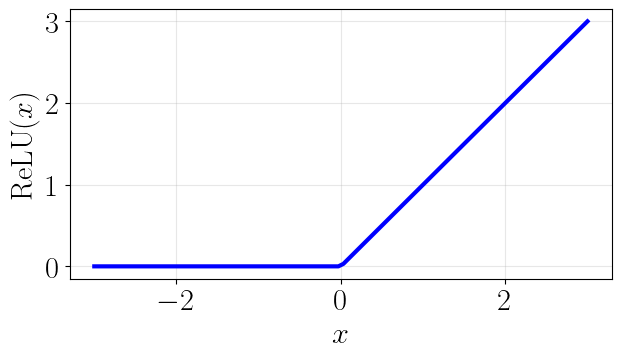

In [26]:
fig, ax = plt.subplots(figsize=plot.wide_figsize)
x = np.linspace(-3, 3, 100)
act = ReLUActivation().forward(x)

ax.plot(x, act, 'b-', linewidth=3)
ax.set_xlabel('$x$')
ax.set_ylabel('$\operatorname{ReLU}(x)$')
ax.grid(True, alpha=0.3)

mlai.write_figure(filename='relu-activation.svg', directory='./deepnn')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/relu-activation.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>The ReLU activation function: zero for negative inputs,
identity for positive inputs.</i>

Other activation functions that are used include hyperbolic tangent,
sigmoid, ELU, leaky ReLU. Although ReLU is often preferred for
simplicity and fast gradient computation.

## Shallow ReLU Networks

A single layer ReLU network is equivalent to a generalised linear model
with a ReLU basis. The difference is that we optimise over the basis
function inputs.

Each hidden unit acts as a basis function with its own kink location and
slope.

In [27]:
from mlai import NeuralNetwork
import inspect
file_path = inspect.getfile(NeuralNetwork)

In [28]:
# %load -s NeuralNetwork /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class NeuralNetwork(Model):
    """
    Neural network model.

    This class implements a neural network model with different basis functions and variable numbers of weight layers.

    :param dimensions: dimensions of the model.
    :type dimensions: list[int]
    :param activations: Activation functions for layers
    :type activations: list[Activation]
    """

    def __init__(self, dimensions, activations):
        """
        Initialise the neural network.
        """
        if len(dimensions) < 2:
            raise ValueError("At least input and output layers must be specified.")
        if len(activations) != len(dimensions) - 1:
            raise ValueError("Number of activation functions must be one less than number of layers.")
        self.dimensions = dimensions
        self.activations = activations
        self.weights = []
        self.biases = []
        for i in range(len(dimensions) - 1):
            weight_matrix = np.random.normal(size=(dimensions[i], dimensions[i + 1])) * np.sqrt(2. / (dimensions[i]+1))
            self.weights.append(weight_matrix)
            bias_vector = np.random.normal(size=dimensions[i+1]) * np.sqrt(2./(dimensions[i]+1))
            self.biases.append(bias_vector)
            
    def predict(self, x):
        """
        Compute output given current basis functions.
        :param x: Input value
        :type x: numpy.ndarray
        :returns: Network output
        :rtype: numpy.ndarray
        """

        nbatch = np.asarray(x).shape[0]
        self.a = []
        self.z = []
        self.a.append(np.asarray(x, dtype=float))
        self.z.append(np.asarray(x, dtype=float))

        for i in range(len(self.weights)):
            self.z.append(self.a[-1] @ self.weights[i] + self.biases[i])
            self.a.append(self.activations[i].forward(self.z[-1]))

        return self.a[-1]
    
    def backward(self, output_gradient):
        """
        Compute gradients using backpropagation through the network.
        
        This method implements the chain rule for computing gradients of the
        loss function with respect to all weight matrices and biases in the network.
        
        Mathematical formulation:
        For layer ℓ and weight matrix W_{ℓ-k}, the gradient is:
        d f_ℓ / d w_{ℓ-k} = [∏_{i=0}^{k-1} W_{ℓ-i} Φ'_{ℓ-i-1}] φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}}
        
        where Φ' is the derivative matrix of the activation function.
        
        :param output_gradient: Gradient of the loss with respect to the output
        :type output_gradient: numpy.ndarray
        :returns: Dictionary containing gradients for weights and biases
        :rtype: dict
        """
        # Initialize gradient storage
        weight_gradients = []
        bias_gradients = []
        
        # Start with the output gradient
        delta = output_gradient
        
        # Backpropagate through each layer (from output to input)
        for i in reversed(range(len(self.weights))):
            # Get the activation derivative for this layer
            activation_derivative = self.activations[i].gradient(self.z[i+1])
            
            # Compute gradient with respect to weights
            # dL/dW_i = (dL/da_i) * (da_i/dz_i) * (dz_i/dW_i)
            # where dz_i/dW_i = a_{i-1}^T
            if i == 0:
                # For first layer, use input
                input_to_layer = self.a[0]
            else:
                input_to_layer = self.a[i]
            
            # Weight gradient: delta * activation_derivative * input^T
            # delta is (batch_size, output_size), activation_derivative is (batch_size, output_size)
            # input_to_layer is (batch_size, input_size)
            # We need: (batch_size, output_size) * (batch_size, output_size) * (batch_size, input_size)^T
            # = (output_size, input_size) for each sample, then sum over batch
            # Weight matrix W_i has shape (input_size, output_size)
            # So gradient should have shape (input_size, output_size)
            weight_grad = np.zeros((self.weights[i].shape[0], self.weights[i].shape[1]))
            for b in range(delta.shape[0]):
                # delta[b] * activation_derivative[b] is (output_size,)
                # input_to_layer[b] is (input_size,)
                # outer product gives (output_size, input_size)
                # But we need (input_size, output_size) to match weight matrix
                weight_grad += np.outer(input_to_layer[b], delta[b] * activation_derivative[b])
            weight_gradients.insert(0, weight_grad)
            
            # Bias gradient: delta * activation_derivative
            # Sum over batch dimension
            bias_grad = np.sum(delta * activation_derivative, axis=0)
            bias_gradients.insert(0, bias_grad)
            
            # Propagate gradient backward through weights
            # delta_{i-1} = W_i^T * (delta_i * activation_derivative_i)
            if i > 0:
                # delta is (batch_size, output_size), activation_derivative is (batch_size, output_size)
                # W_i is (input_size, output_size), so W_i^T is (output_size, input_size)
                # We need: (batch_size, output_size) @ (output_size, input_size) = (batch_size, input_size)
                delta = (delta * activation_derivative) @ self.weights[i].T
        
        return {
            'weight_gradients': weight_gradients,
            'bias_gradients': bias_gradients
        }
    
    def compute_gradient_for_layer(self, layer_idx, output_gradient):
        """
        Compute gradient for a specific layer using the chain rule formula.
        
        This implements the mathematical formula you derived:
        d f_ℓ / d w_{ℓ-k} = [∏_{i=0}^{k-1} W_{ℓ-i} Φ'_{ℓ-i-1}] φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}}
        
        :param layer_idx: Index of the layer to compute gradient for
        :type layer_idx: int
        :param output_gradient: Gradient of the loss with respect to the output
        :type output_gradient: numpy.ndarray
        :returns: Gradient matrix for the specified layer
        :rtype: numpy.ndarray
        """
        if layer_idx >= len(self.weights):
            raise ValueError(f"Layer index {layer_idx} out of range. Network has {len(self.weights)} layers.")
        
        # Start with output gradient
        gradient = output_gradient
        
        # Apply chain rule: multiply by weight matrices and activation derivatives
        # from output layer down to the target layer
        for i in reversed(range(layer_idx + 1, len(self.weights))):
            # Get activation derivative for layer i
            activation_derivative = self.activations[i].gradient(self.z[i+1])
            
            # Apply chain rule: gradient = W^T * (gradient * activation_derivative)
            gradient = (gradient * activation_derivative) @ self.weights[i].T
        
        # Get activation derivative for target layer
        activation_derivative = self.activations[layer_idx].gradient(self.z[layer_idx+1])
        
        # Get input to target layer
        if layer_idx == 0:
            input_to_layer = self.a[0]
        else:
            input_to_layer = self.a[layer_idx]
        
        # Compute final gradient using outer product
        # This implements: φ_{ℓ-k-1}^T ⊗ I_{d_{ℓ-k}} part of the formula
        # Sum over batch dimension
        final_gradient = np.zeros((self.weights[layer_idx].shape[0], self.weights[layer_idx].shape[1]))
        for b in range(gradient.shape[0]):
            # gradient[b] * activation_derivative[b] is (output_size,)
            # input_to_layer[b] is (input_size,)
            # outer product gives (output_size, input_size)
            # But we need (input_size, output_size) to match weight matrix
            final_gradient += np.outer(input_to_layer[b], gradient[b] * activation_derivative[b])
        
        return final_gradient


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import mlai
import mlai.plot as plot

In [30]:
x1 = np.linspace(-2, 2, 50)
x2 = np.linspace(-2, 2, 50)
X1, X2 = np.meshgrid(x1, x2)
nn = NeuralNetwork([2, 10, 1], [ReLUActivation(), LinearActivation()])
X_pred = np.hstack([X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis]])
f_pred = nn.predict(X_pred)

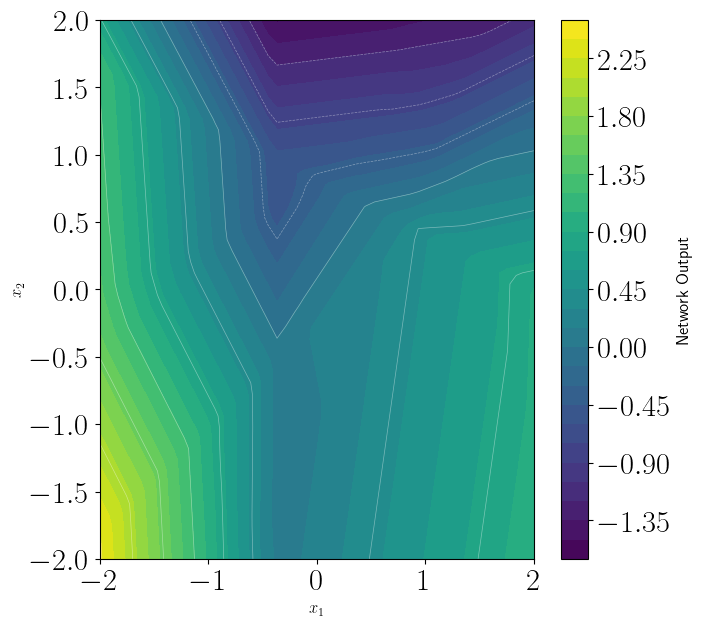

In [31]:
fig, ax = plt.subplots(figsize = plot.big_figsize)
    
levels = 30
contour = ax.contourf(X1, X2, f_pred.reshape(50, 50), levels=levels, cmap='viridis')

contour_lines = ax.contour(X1, X2, f_pred.reshape(50, 50), 
                          levels=10, colors='white', alpha=0.4, linewidths=0.5)

ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)

# Enhanced colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Network Output', fontsize=12)

mlai.write_figure(filename='relu-network-2d.svg', directory='./deepnn')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/relu-network-2d.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>Output of a 2D ReLU network with 3 hidden units, showing
piecewise-linear regions.</i>

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [33]:
# Cell 2: Create Synthetic Data
def create_synthetic_data(n_samples=100, task='regression'):
    """Create synthetic datasets for demonstration."""
    np.random.seed(42)
    
    if task == 'regression':
        # Non-linear regression: y = x1^2 + x2^2 + noise
        X = np.random.randn(n_samples, 2)
        y = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1) + 0.1 * np.random.randn(n_samples, 1)
        return X, y
    
    elif task == 'classification':
        # Binary classification: x1^2 + x2^2 > 1
        X = np.random.randn(n_samples, 2)
        y = ((X[:, 0]**2 + X[:, 1]**2) > 1.0).astype(float).reshape(-1, 1)
        return X, y

In [34]:
x1 = np.linspace(-2, 2, 50)
x2 = np.linspace(-2, 2, 50)
X1, X2 = np.meshgrid(x1, x2)

# Create and use network
nn = NeuralNetwork([2, 10, 1], [ReLUActivation(), LinearActivation()])

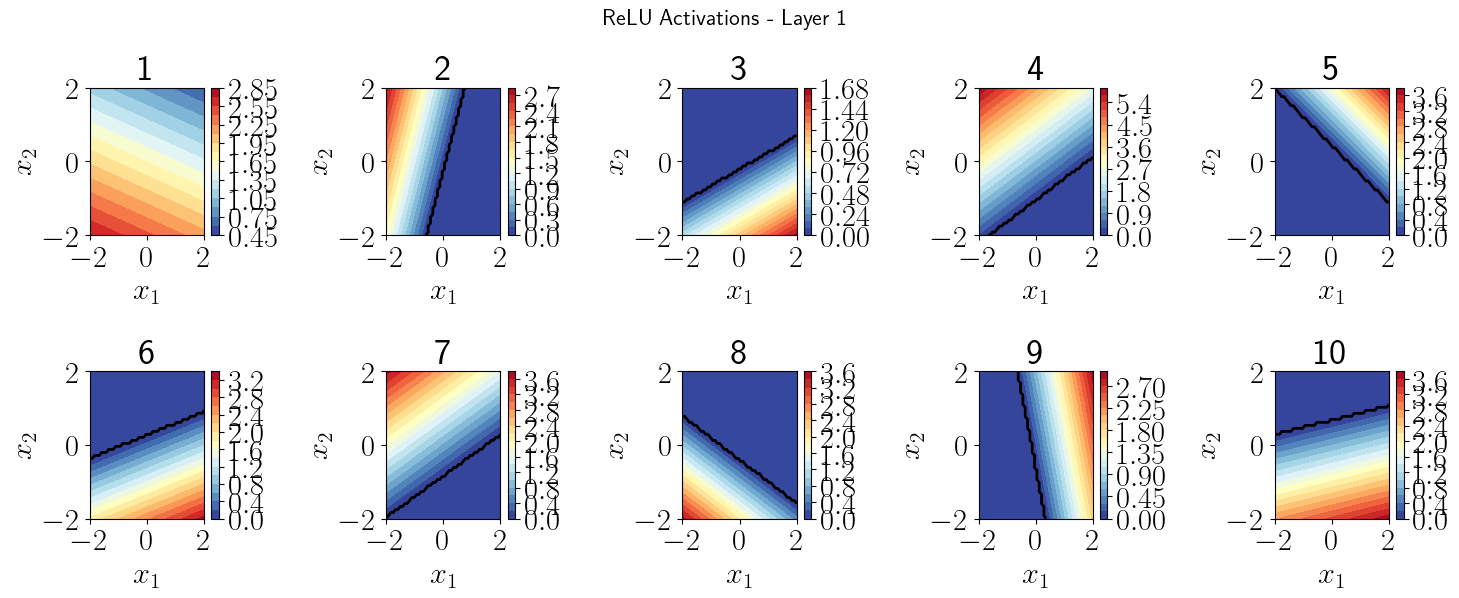

In [35]:
plot.visualise_relu_activations(nn, X1, X2, layer_idx=0, directory="./deepnn")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/relu-activations.svg" class="" width="50%" style="vertical-align:middle;">

Figure: <i>Decision boundaries for the ReLU network.</i>

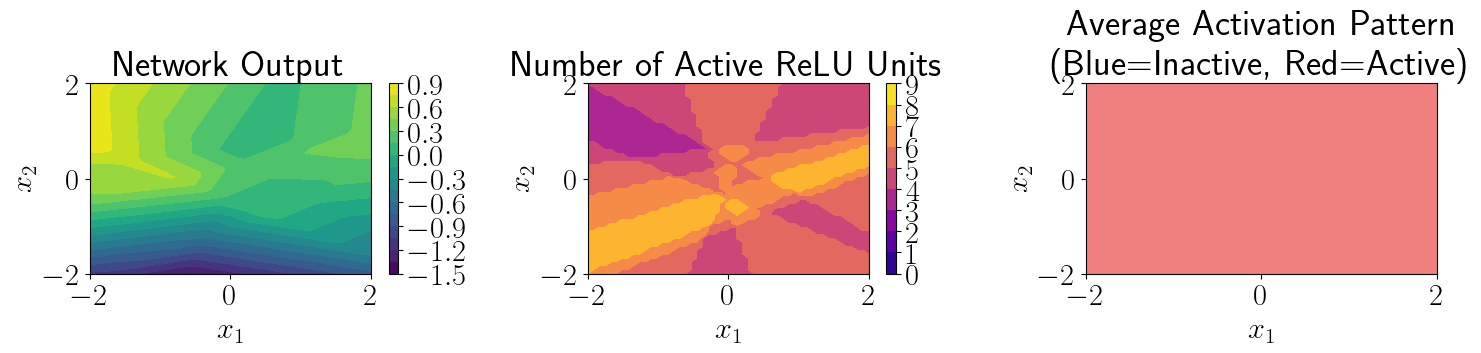

In [36]:
plot.visualise_activation_summary(nn, X1, X2, layer_idx=0, directory="./deepnn")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/activation-summary.svg" class="" width="50%" style="vertical-align:middle;">

Figure: <i>Decision boundaries for the ReLU network.</i>

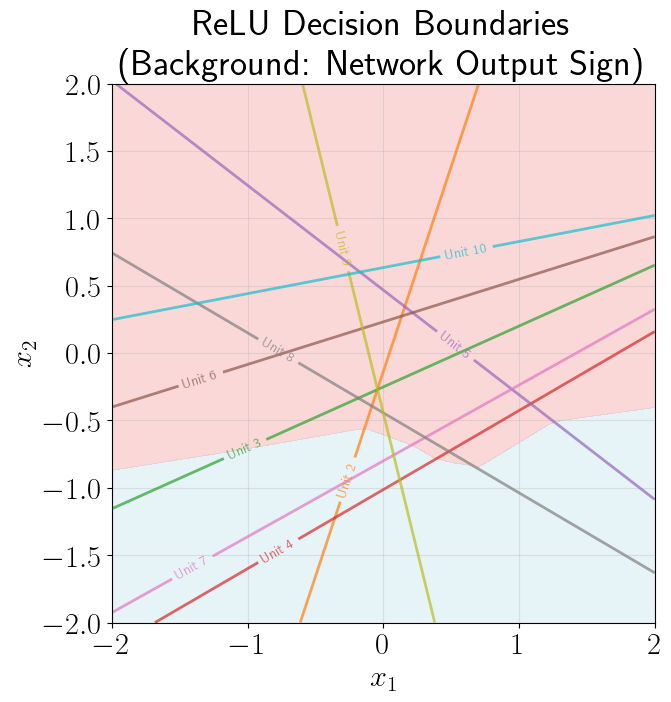

In [37]:
plot.visualise_decision_boundaries(nn, X1, X2, layer_idx=0, directory='./deepnn')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/decision-boundaries.svg" class="" width="50%" style="vertical-align:middle;">

Figure: <i>Decision boundaries for the ReLU network.</i>

## Depth vs Width: Representation Power

ReLU networks implement piecewise-linear functions. Increasing the width
of the network increases the number of linear pieces roughly linearly,
increasing the depth increases them exponentially. This exponential
growth in representational power with depth is what makes deep networks
so powerful for complex function approximation.

## Sawtooth Construction

The sawtooth construction provides an example of how depth can to
exponential growth in representational power. This 1D construction shows
how each layer doubles the number of linear segments.

In higher dimensions, these become polyhedral regions with constant
gradients inside each region. Each layer creates more complex boundaries
between linear regions.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import mlai
import mlai.plot as plot

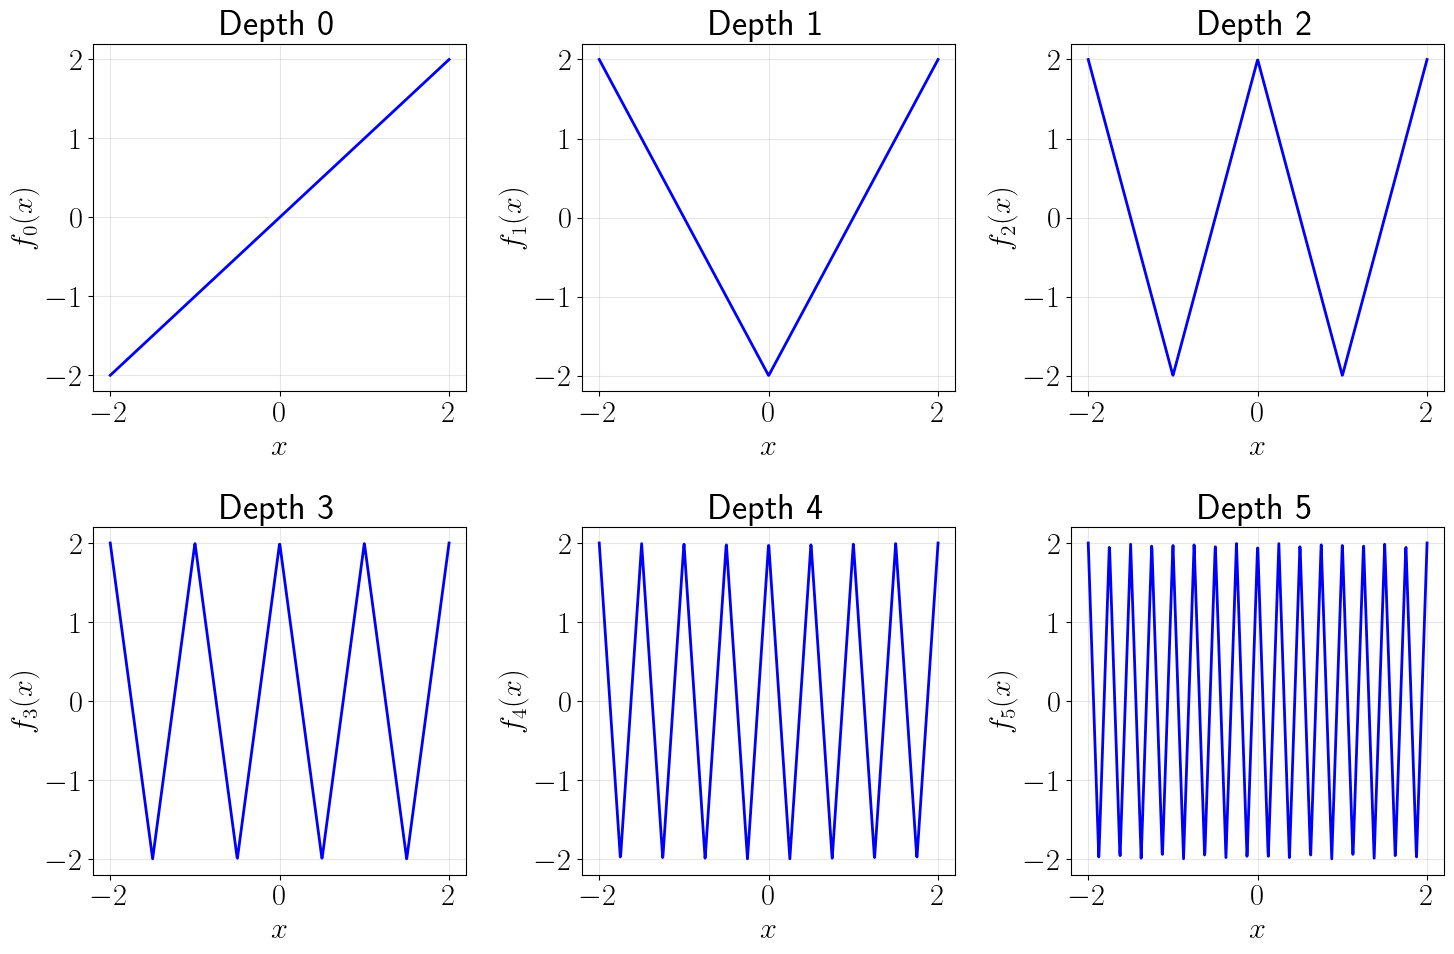

In [39]:
# Sawtooth construction visualization
def sawtooth_layer(x, layer):
    """Apply sawtooth construction for given layer"""
    if layer == 0:
        return x
    else:
        prev = sawtooth_layer(x, layer - 1)
        return 2 * np.abs(prev) - 2

# Create input data
x = np.linspace(-2, 2, 1000)

# Plot different depths
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for depth in range(6):
    y = sawtooth_layer(x, depth)
    axes[depth].plot(x, y, 'b-', linewidth=2)
    axes[depth].set_title(f'Depth {depth}')
    axes[depth].set_xlabel('$x$')
    axes[depth].set_ylabel('$f_{' + str(depth) + '}(x)$')
    axes[depth].grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure(filename='sawtooth-construction.svg', directory='./deepnn')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/sawtooth-construction.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Sawtooth construction showing exponential growth of linear
segments with depth. Each layer doubles the number of kinks.</i>

## Higher-dimensional Geometry

In 2D, ReLU networks partition input space into many polygonal regions.
Within each region the mapping is linear, yet globally the function is
continuous because adjacent regions meet with consistent boundary
values. Depth increases the number and intricacy of these regions across
layers.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import mlai
import mlai.plot as plot

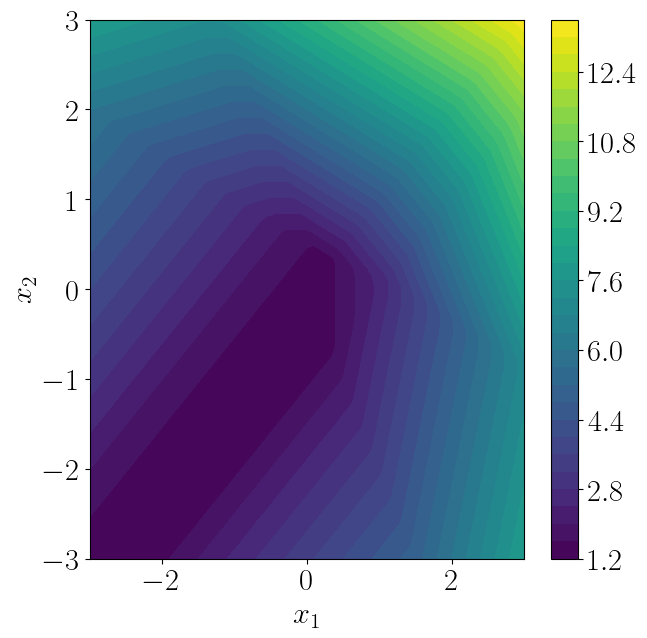

In [41]:
nn = NeuralNetwork([2, 4, 4, 1], [ReLUActivation(), ReLUActivation(), LinearActivation()])

# Create 2D input grid
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)

# Deep ReLU network: 2 inputs -> 4 hidden -> 4 hidden -> 1 output
# Layer 1 weights and biases
nn.weights[0] = np.array([[1, 0.5], [0.5, 1], [-0.5, 0.5], [0.5, -0.5]]).T
nn.biases[0] = np.array([0, -0.5, 0.5, 0])

# Layer 2 weights and biases  
nn.weights[1] = np.array([[1, 0.5, -0.5, 0.5], [0.5, 1, 0.5, -0.5], [-0.5, 0.5, 1, 0.5], [0.5, -0.5, 0.5, 1]]).T
nn.biases[1] = np.array([0, -0.5, 0.5, 0])

# Layer 3 weights and biases
nn.weights[2] = np.ones((4, 1))
nn.biases[2] = np.zeros(1)

f = nn.predict(np.hstack([X1.flatten()[:, np.newaxis], X2.flatten()[:, np.newaxis]]))

# Plot the result
fig, ax = plt.subplots(figsize=plot.big_figsize)
contour = ax.contourf(X1, X2, f.reshape(X1.shape), levels=30, cmap='viridis')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.colorbar(contour, ax=ax)

mlai.write_figure(filename='deep-relu-2d.svg', directory='./deepnn')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/deep-relu-2d.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>Deep ReLU network output showing complex piecewise-linear
regions in 2D. Each region has constant gradient, but the overall
function is continuous.</i>

## Chain Rule and Back Propgation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/back-propagation-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/back-propagation-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

When Rosenblatt built his Perceptron model in 1957, he used multiple
layers of units, that he called association units, to take advantage of
the deep structure he gave these units random weights. In modern deep
learning we adjust these weights to minimise the error.

From the basis function perspective, we have parameters in our basis
function vectors, $\boldsymbol{ \phi}(\mathbf{ x}; \mathbf{V})$ that can
be adjusted. They are non-linearly related to the output so that makes
these models non-linear both in terms of the dependence on inputs *and*
the dependence on parameters.

To compute derivatives we now need to compute the derivation of the
system with respect to the basis functions. $$
f(\mathbf{ x}_i) = \mathbf{ w}^\top \boldsymbol{ \phi}(\mathbf{ x}_i; \mathbf{V}).
$$ We already have the gradient with respect to $\mathbf{ w}$, which is
simply. $$
\frac{\text{d}f_i}{\text{d}\mathbf{ w}} = \boldsymbol{ \phi}(\mathbf{ x}_i; \mathbf{V}),
$$

$$\frac{\text{d}f_i}{\text{d}\mathbf{V}} = \frac{\text{d}f_i}{\text{d}\boldsymbol{ \phi}_i}\frac{\text{d}\boldsymbol{ \phi}_i}{\text{d} \mathbf{V}}$$

we now need the gradient with respect to $\mathbf{ v}$. This can be
computed by the chain rule as, $$
\frac{\text{d}f_i}{\text{d}\mathbf{V}} = \frac{\text{d}f_i}{\text{d}\boldsymbol{ \phi}_i}\frac{\text{d}\boldsymbol{ \phi}_i}{\text{d} \mathbf{V}}.
$$ But we have to be careful here. This is the chain rule, but it
contains a new challenge,
$\frac{\text{d}\boldsymbol{ \phi}_i}{\text{d} \mathbf{V}}$ is the
derivative of a *vector* with respect to a *matrix*. How do we deal with
this?

## Matrix Vector Chain Rule

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_maths/includes/matrix-vector-chain-rule.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_maths/includes/matrix-vector-chain-rule.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

There are several standards for how to perform the chain rule with
multivariate calculus. My favourite is from Mike Brookes. The details
are given by Brookes (2005).

How do we write the derivative of a vector with respect to a matrix or a
matrix with a respect to a matrix? In Brookes’s approach the first rule
is that you never compute these directly. Instead you form an
intermediate *stacking* operation.

## Matrix Stacking

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_maths/includes/matrix-stacking.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_maths/includes/matrix-stacking.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

$$\mathbf{a} = \begin{bmatrix}
\mathbf{a}_{:, 1}\\
\mathbf{a}_{:, 2}\\
\vdots\\
\mathbf{a}_{:, q}
\end{bmatrix}$$

A stacking operation takes a matrix, $\mathbf{A}$, and rewrites it as a
vector where each column of $\mathbf{A}$ is stacked on top of one
another to give a new vector $\mathbf{a}$, $$
\mathbf{a} = \begin{bmatrix}
\mathbf{a}_{:, 1}\\
    \mathbf{a}_{:, 2}\\
    \vdots\\
    \mathbf{a}_{:, q}
    \end{bmatrix}
$$

$$\frac{\text{d} \mathbf{a}}{\text{d} \mathbf{b}} \in \Re^{m \times n}$$

Next we consider the derivative of one vector with respect to another as
$$ \frac{\text{d} \mathbf{a}}{\text{d} \mathbf{b}} \in
\Re^{m \times n} 
$$ if $\mathbf{a} \in \Re^{m \times 1}$ and
$\mathbf{b} \in \Re^{n \times 1}$.

This now means that to obtain matrix-matrix derivatives we make use of
$\mathbf{C}:$: to indicate a vector formed from the matrix $\mathbf{C}$
by stacking the columns of $\mathbf{C}$ to form a $\Re^{m n \times 1}$
vector if $\mathbf{C} \in \Re^{m \times n}$.

$$\frac{\text{d} \mathbf{E}}{\text{d} \mathbf{C}} \in \Re^{pq \times mn}$$

Under this notation we can write the derivative of a matrix
$\mathbf{E} \in \Re^{p \times q}$ with respect to $\mathbf{C}$ as
$\frac{\text{d} \mathbf{E}}{\text{d} \mathbf{C}} \in \Re^{p q \times m n}$.
This notation makes it easier to apply the chain rule while maintaining
matrix notation.

This entails the use of Kronecker products, we denote the Kronecker
product of $\mathbf{F}$ and $\mathbf{G}$ as
$\mathbf{F} \otimes \mathbf{G}$.

## Kronecker Products

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_maths/includes/kronecker-products.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_maths/includes/kronecker-products.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

## Visual Examples

In [42]:
import mlai.plot as plot

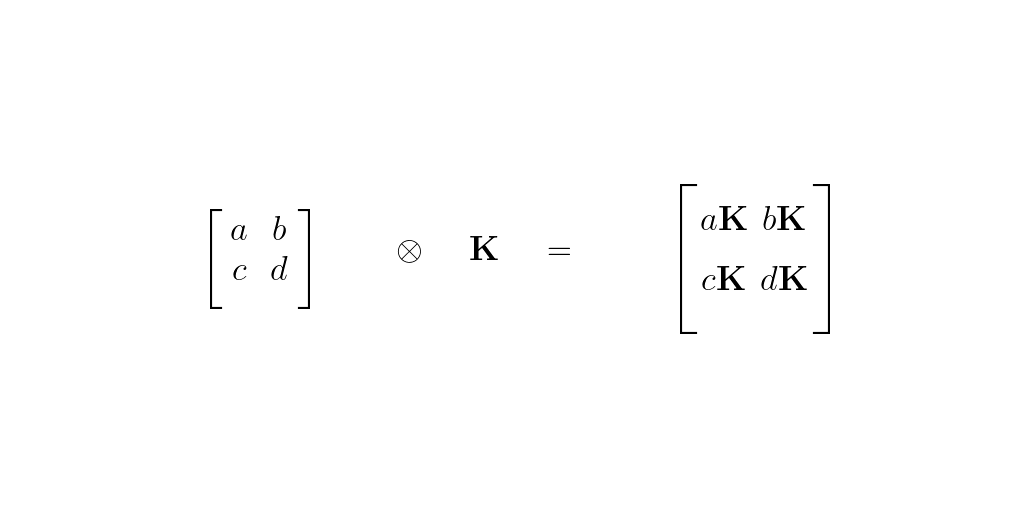

In [43]:
plot.kronecker_illustrate(diagrams='./maths')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//maths/kronecker_illustrate.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Illustration of the Kronecker product.</i>

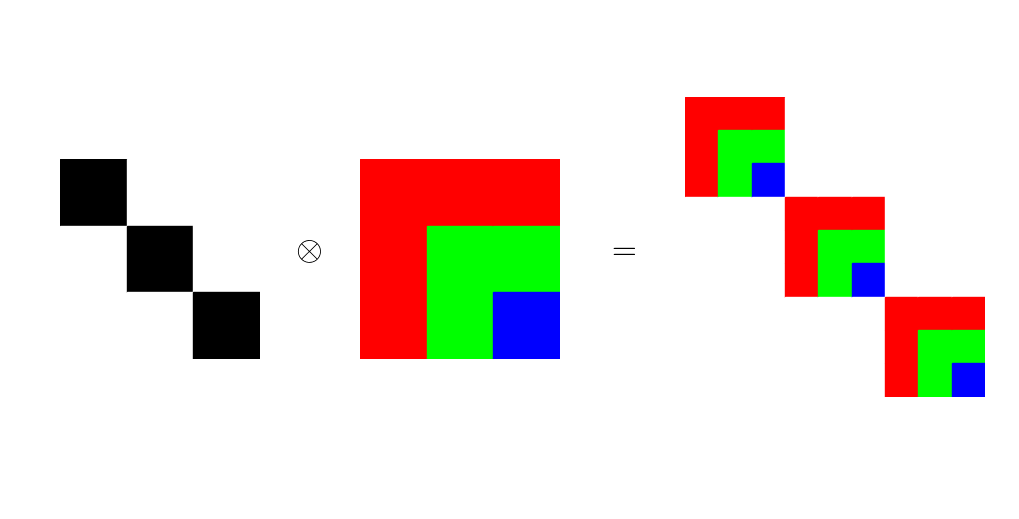

In [44]:
plot.kronecker_IK(diagrams='./maths')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//maths/kronecker_IK.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Kronecker product between two matrices.</i>

$$(\mathbf{A} \otimes \mathbf{B})_{ij} = a_{i_1 j_1} b_{i_2 j_2}$$

The Kronecker product of two matrices $\mathbf{A} \in \Re^{m \times n}$
and $\mathbf{B} \in \Re^{p \times q}$ is defined as: $$
(\mathbf{A} \otimes \mathbf{B})_{ij} = a_{i_1 j_1} b_{i_2 j_2}
$$ where $i = (i_1-1)p + i_2$ and $j = (j_1-1)q + j_2$.

## Matrix Stacking and Kronecker Products

There are two main ways to stack matrices:

**Column Stacking**: Each column of $\mathbf{A}$ becomes a block: $$
\mathbf{a} = \begin{bmatrix}
\mathbf{a}_{:, 1}\\
\mathbf{a}_{:, 2}\\
\vdots\\
\mathbf{a}_{:, n}
\end{bmatrix}
$$

**Row Stacking**: Each row of $\mathbf{A}$ becomes a block: $$
\mathbf{a} = \begin{bmatrix}
\mathbf{a}_{1, :}\\
\mathbf{a}_{2, :}\\
\vdots\\
\mathbf{a}_{m, :}
\end{bmatrix}
$$

## Computational Advantages

The Kronecker structure provides significant computational advantages

1.  **Memory efficiency**: Instead of storing an $n \times n$ matrix, we
    store smaller component matrices
2.  **Computational efficiency**: Matrix operations scale better with
    Kronecker structure
3.  **Numerical stability**: Often more stable than direct computation
    of large matrices

$$(\mathbf{E}:)^{\top} \mathbf{F} \otimes \mathbf{G}=\left(\left(\mathbf{G}^{\top} \mathbf{E F}\right):\right)^{\top}$$

In most cases Kronecker products they arise below they are later removed
using this relationship $$
(\mathbf{E}:)^{\top} \mathbf{F} \otimes \mathbf{G}=\left(\left(\mathbf{G}^{\top} \mathbf{E F}\right):\right)^{\top}
$$ this form typically arises whenever the chain rule is applied,

$$\frac{\text{d} E}{\text{d} \mathbf{H}:} \frac{\text{d} \mathbf{H}:}{\text{d} \mathbf{J}:}=\frac{\text{d} E}{\text{d} \mathbf{J}:}$$

$$\frac{\text{d}\mathbf{H}}{\text{d} \mathbf{J}} = \mathbf{F} \otimes \mathbf{G}$$

$$ 
\frac{\text{d} E}{\text{d} \mathbf{H}:} \frac{\text{d}
\mathbf{H}:}{\text{d} \mathbf{J}:}=\frac{\text{d}
E}{\text{d} \mathbf{J}:}, 
$$ as we normally find that
$\frac{\text{d} \mathbf{H}}{\text{d} \mathbf{J}}$ has the form of a
Kronecker product, $$
\frac{\text{d}\mathbf{H}}{\text{d} \mathbf{J}} = \mathbf{F} \otimes \mathbf{G}
$$ and we expect the result of $\frac{\text{d} E}{\text{d} \mathbf{H}}$
and $\frac{\text{d} E}{\text{d} \mathbf{J}}$ to be in the form
$(\mathbf{E}:)^\top$.

$$\mathbf{F}^{\top} \otimes \mathbf{G}^{\top}=(\mathbf{F} \otimes \mathbf{G})^{\top}$$

$$(\mathbf{E} \otimes \mathbf{G})(\mathbf{F} \otimes \mathbf{H})=\mathbf{E F} \otimes \mathbf{G H}$$

The following two identities for Kronecker products will also prove
useful. $$
\mathbf{F}^{\top} \otimes \mathbf{G}^{\top}=(\mathbf{F} \otimes \mathbf{G})^{\top}
$$ and $$
(\mathbf{E} \otimes \mathbf{G})(\mathbf{F} \otimes
\mathbf{H})=\mathbf{E F} \otimes \mathbf{G H}
$$

$$\frac{\text{d} E}{\text{d} \mathbf{J}:}=\left(\left(\frac{\text{d} E}{\text{d} \mathbf{J}}\right):\right)^{\top}$$

Generally we will use two ways of writing the derivative of a scalar
with respect to a matrix, $\frac{\text{d} E}{\text{d} \mathbf{J}}$ and
$\frac{\text{d} E}{\text{d} \mathbf{J}}$, the first being a row vector
and the second is a matrix of the same dimension of $\mathbf{J}$. The
second representation is more convenient for summarising the result, the
first is easier to wield when computing the result. The equivalence of
the representations is given by $$ 
\frac{\text{d} E}{\text{d}
\mathbf{J}:}=\left(\left(\frac{\text{d} E}{\text{d}
\mathbf{J}}\right):\right)^{\top}.
$$

## Useful Multivariate Derivatives

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_maths/includes/more-useful-matrix-derivatives.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_maths/includes/more-useful-matrix-derivatives.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

By defining our multivariate derivatives through vectors, we can now
write down the results for some more useful multivariate derivatives.
Let’s start with $\mathbf{b} = \mathbf{A}\mathbf{x}$ and assume we want
the gradient of $\mathbf{b}$ with respect to $\mathbf{A}$. We assume
that $\mathbf{A} \in \Re^{m\times n}$. To derive the gradient we’ll get
there slightly indirectly and consider the gradient of $\mathbf{b}$
first,

$$\frac{\text{d}}{\text{d} \mathbf{a^\prime}} \mathbf{A} \mathbf{x}$$

$$
\frac{\text{d}}{\text{d} \mathbf{a^\prime}} \mathbf{A} \mathbf{x}
$$ which must be a matrix of size $m \times mn$. Here we’ve taken the
unusual step of defining
$\mathbf{a^\prime} = \left(\mathbf{A}^\top\right):$. We construct this
form because it means that we are forming $\mathbf{a}^\prime$ by
stacking the columns of $\mathbf{A}^\top$, which are the rows of
$\mathbf{A}$.

$$\mathbf{A}\mathbf{x} = \begin{bmatrix}
\mathbf{a}_{1, :}^\top \mathbf{x} \\
\mathbf{a}_{2, :}^\top \mathbf{x} \\
\vdots \\
\mathbf{a}_{m, :}^\top \mathbf{x}
\end{bmatrix}$$

This makes the derivation straightforward by inspection because the
vector $\mathbf{b} = \mathbf{A}\mathbf{x}$ is a vector formed of inner
products of the different *rows* of $\mathbf{A}$, $$
\mathbf{A}\mathbf{x} = \begin{bmatrix}
\mathbf{a}_{1, :}^\top \mathbf{x} \\
\mathbf{a}_{2, :}^\top \mathbf{x} \\
\vdots \\
\mathbf{a}_{m, :}^\top \mathbf{x}
\end{bmatrix}.
$$ Recall that the gradient $$
\frac{\text{d}\mathbf{a}_{i,:}^\top \mathbf{x}}{\text{d}\mathbf{a}_{i,:}} = \mathbf{x},
$$ where $\mathbf{a}_{i, :}$ is a vector formed from the $i$th column of
$\mathbf{A}$. So this means means that we should expect our result to
consist only of repeated versions of $\mathbf{x}$. From our definition
of vector derivatives, we know we are looking for a result with $m$ rows
and $nm$ columns. This is where the Kronecker product comes in.

$$\mathbf{I}_m \otimes \mathbf{x}^\top = \begin{bmatrix}
\mathbf{x}^\top & \mathbf{0}& \cdots & \mathbf{0}\\
\mathbf{0}& \mathbf{x}^\top & \cdots & \mathbf{0}\\
\vdots & \vdots & \ddots & \vdots \\
\mathbf{0}& \mathbf{0}& \cdots& \mathbf{x}^\top
\end{bmatrix}$$

We note that $\mathbf{I}\otimes \mathbf{x}^\top$ provides a tiling of
$\mathbf{x}$ of the form, $$
\mathbf{I}_m \otimes \mathbf{x}^\top = \begin{bmatrix}
\mathbf{x}^\top & \mathbf{0}& \cdots & \mathbf{0}\\
\mathbf{0}& \mathbf{x}^\top & \cdots & \mathbf{0}\\
\vdots & \vdots & \ddots & \vdots \\
\mathbf{0}& \mathbf{0}& \cdots& \mathbf{x}^\top
\end{bmatrix}.
$$ where $\mathbf{I}_m$ is the $m$ dimensional identity matrix.

$$\frac{\text{d}}{\text{d} \mathbf{a^\prime}} \mathbf{A} \mathbf{x} = \mathbf{I}_{m} \otimes \mathbf{x}^\top$$

So this means we can write, $$
\frac{\text{d}}{\text{d} \mathbf{a^\prime}} \mathbf{A} \mathbf{x} = \mathbf{I}_{m} \otimes \mathbf{x}^\top
$$ because we can see that each row of this matrix contains the
derivative of $b_i = \mathbf{a}_{i, :}^\top \mathbf{x}$ with respect to
$\mathbf{a}^\prime$, wherewe constructed $\mathbf{a}^\prime$ to be the
stacking of the *rows* of $\mathbf{A}$. The elements are zero apart from
those associated with $\mathbf{a}_{i, :}$ where the elements are
$\mathbf{x}$.

$$\frac{\text{d}}{\text{d} \mathbf{a}} \mathbf{A} \mathbf{x} = \mathbf{x}^\top \otimes \mathbf{I}_{m}$$

$$\mathbf{x}^\top \otimes \mathbf{I}_{m} = \begin{bmatrix}
x_1 \mathbf{I}_m & x_2 \mathbf{I}_m & \cdots & x_n \mathbf{I}_m
\end{bmatrix}$$

Now, to get the gradient with respect to $\mathbf{a} = \mathbf{A}:$
instead of with respect to $\mathbf{a}^\prime$ we reverse the order of
the Kronecker product $$
\frac{\text{d}}{\text{d} \mathbf{a}} \mathbf{A} \mathbf{x} = \mathbf{x}^\top \otimes \mathbf{I}_{m} 
$$ which disperses the elements of $\mathbf{x}$ across the matrix, $$
\mathbf{x}^\top \otimes \mathbf{I}_{m}  = \begin{bmatrix}
x_1 \mathbf{I}_m & x_2 \mathbf{I}_m & \cdots & x_n \mathbf{I}_m
\end{bmatrix}
$$ and is the correct for when we are stacking the columns of \$.

## Chain Rule for Neural Networks

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/chain-rule-neural-network.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/chain-rule-neural-network.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We’re now in a position to write down the chain rule for neural
networks.

$$\mathbf{ f}_\ell= \mathbf{W}_\ell\boldsymbol{ \phi}_{\ell-1}$$

$$\boldsymbol{ \phi}_{\ell} = \boldsymbol{ \phi}_{\ell}(\mathbf{ f}_{\ell})$$

To make our derivations general, we will split up the neural network in
the following way. First we describe the activations at layer $\ell$,
$\mathbf{ f}_\ell$ given the basis functions from the previous layer,
$\boldsymbol{ \phi}_{\ell-1}$ in terms of the weight matrix,
$\mathbf{W}_\ell$. $$
\mathbf{ f}_\ell= \mathbf{W}_\ell\boldsymbol{ \phi}_{\ell-1}
$$ where the basis vector at any given layer $\ell$ is given by applying
the basis functions to the activations, $$
\boldsymbol{ \phi}_{\ell} = \boldsymbol{ \phi}_{\ell}(\mathbf{ f}_{\ell}),
$$ where $\mathbf{ f}_{\ell}(\cdot)$ represents the form of the basis
functions at the $\ell$th layer.

$$f_1 = \mathbf{W}_1 \mathbf{ x}$$

$$\mathbf{h} = \mathbf{h}(\mathbf{ f}_L)$$

These two equations give us everything we need apart from the first
layer and final layers where we have $$
f_1 = \mathbf{W}_1 \mathbf{ x}
$$ for the first layer. Here we are *not* showing the index on the data
point $i$ to avoid cluttering the notation. In the final layer we have
the output of the network given by the inverse link function, $$
\mathbf{h} = \mathbf{h}(\mathbf{ f}_L).
$$ so we can assume dummy-basis functions for the output layer and take
$\mathbf{h} = \boldsymbol{ \phi}_L$.

This formalism isn’t fully general as it doesn’t capture the possibility
of skip connections where a weight matrix connects e.g. basis functions
from layer $\ell-2$ to the activations of layer $\ell$. But it’s
sufficient to capture the main aspects of deep neural network gradients.

These fundamental operations now allow us to use our matrix derivative
rules to compute the gradients of the neural network with respect to any
layer of weights. To do this we need three fundamental gradients. First
the activation gradient,

$$\frac{\text{d}\mathbf{ f}_\ell}{\text{d}\mathbf{ w}_\ell} = \boldsymbol{ \phi}_{\ell-1}^\top \otimes \mathbf{I}_{d_\ell}$$

$\tfrac{\text{d}\mathbf{ f}_\ell}{\text{d}\mathbf{ w}_\ell}$ where we
have defined $\mathbf{ f}_\ell= (\mathbf{ f}_\ell)\!:$. This gradient is
between a $d_\ell$ dimensional vector, $\mathbf{ f}_\ell$, and a
$(d_{\ell-1})d\times 1$ dimensional vector, so it produces a matrix that
is $d_\ell\times (d_{\ell-1} d)$, $$
\frac{\text{d}\mathbf{ f}_\ell}{\text{d}\mathbf{ w}_\ell}
= \boldsymbol{ \phi}_{\ell-1}^\top \otimes \mathbf{I}_{d_\ell}.  
$$

$$\frac{\text{d}\boldsymbol{ \phi}_{\ell}}{\text{d} \mathbf{ f}_{\ell}} = \boldsymbol{ \Phi}^\prime$$

$$\frac{\text{d}\phi_i^{(\ell)}(\mathbf{ f}_{\ell})}{\text{d} f_j^{(\ell)}}$$

We represent the gradient $$
\frac{\text{d}\boldsymbol{ \phi}_{\ell}}{\text{d} \mathbf{ f}_{\ell}} = \boldsymbol{ \Phi}^\prime
$$ which is a $d_\ell\times d_\ell$ sized matrix whose elements are
given by $$
\frac{\text{d}\phi_i^{(\ell)}(\mathbf{ f}_{\ell})}{\text{d} f_j^{(\ell)}}
$$ where $\phi_i^{(\ell)}(\mathbf{ f}_{\ell})$ is the $i$th basis
function from the $\ell$th layer and $f_j^{(\ell)}$ is the $j$th
activation from the same layer. If
$\phi_i^{(\ell)}(\mathbf{ f}_{\ell}) = \phi_i^{(\ell)}(f^{(\ell)}_i)$
then this matrix is diagonal.

In [45]:
from mlai import Activation

In [46]:
from mlai import LinearActivation
import inspect
file_path = inspect.getfile(LinearActivation)

In [47]:
# %load -s LinearActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class LinearActivation(Activation):
    """
    Linear activation function (identity) with gradient.
    
    This activation function returns the input unchanged and has a gradient
    of 1 everywhere. Useful for output layers or when no activation is desired.
    """
    
    def forward(self, x):
        """
        Forward pass: returns input unchanged.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Input array unchanged
        :rtype: numpy.ndarray
        """
        return x
    
    def gradient(self, x):
        """
        Gradient of linear activation (always 1).
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Array of ones with same shape as input
        :rtype: numpy.ndarray
        """
        return np.ones_like(x)


In [48]:
from mlai import ReLUActivation
import inspect
file_path = inspect.getfile(ReLUActivation)

In [49]:
# %load -s ReLUActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class ReLUActivation(Activation):
    """
    ReLU activation function with gradient.
    
    ReLU (Rectified Linear Unit) activation function that returns max(0, x)
    with appropriate gradient computation.
    """
    
    def forward(self, x):
        """
        Forward pass: ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: ReLU activated array
        :rtype: numpy.ndarray
        """
        return x * (x > 0)
    
    def gradient(self, x):
        """
        Gradient of ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array (1 where x > 0, 0 elsewhere)
        :rtype: numpy.ndarray
        """
        return (x > 0).astype(float)


In [50]:
from mlai import SigmoidActivation
import inspect
file_path = inspect.getfile(SigmoidActivation)

In [51]:
# %load -s SigmoidActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class SigmoidActivation(Activation):
    """
    Sigmoid activation function with gradient.
    
    Sigmoid activation function that maps inputs to (0, 1) range
    with appropriate gradient computation.
    """
    
    def forward(self, x):
        """
        Forward pass: sigmoid activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Sigmoid activated array
        :rtype: numpy.ndarray
        """
        return 1. / (1. + np.exp(-x))
    
    def gradient(self, x):
        """
        Gradient of sigmoid activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array
        :rtype: numpy.ndarray
        """
        s = self.forward(x)
        return s * (1 - s)


In [52]:
from mlai import SoftReLUActivation
import inspect
file_path = inspect.getfile(SoftReLUActivation)

In [53]:
# %load -s SoftReLUActivation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class SoftReLUActivation(Activation):
    """
    Soft ReLU (softplus) activation function with gradient.
    
    Soft ReLU is a smooth approximation to ReLU that is differentiable
    everywhere. It computes log(1 + exp(x)) with appropriate gradient.
    """
    
    def forward(self, x):
        """
        Forward pass: soft ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Soft ReLU activated array
        :rtype: numpy.ndarray
        """
        return np.log(1. + np.exp(x))
    
    def gradient(self, x):
        """
        Gradient of soft ReLU activation.
        
        :param x: Input array
        :type x: numpy.ndarray
        :returns: Gradient array (sigmoid of input)
        :rtype: numpy.ndarray
        """
        return 1. / (1. + np.exp(-x))


In [54]:
x = np.linspace(-3, 3, 100)
activations = {
    'Linear': LinearActivation(),
    'ReLU': ReLUActivation(),
    'Sigmoid': SigmoidActivation(),
    'Soft ReLU': SoftReLUActivation()
}

In [55]:
import matplotlib.pyplot as plt
import mlai
from mlai import plot

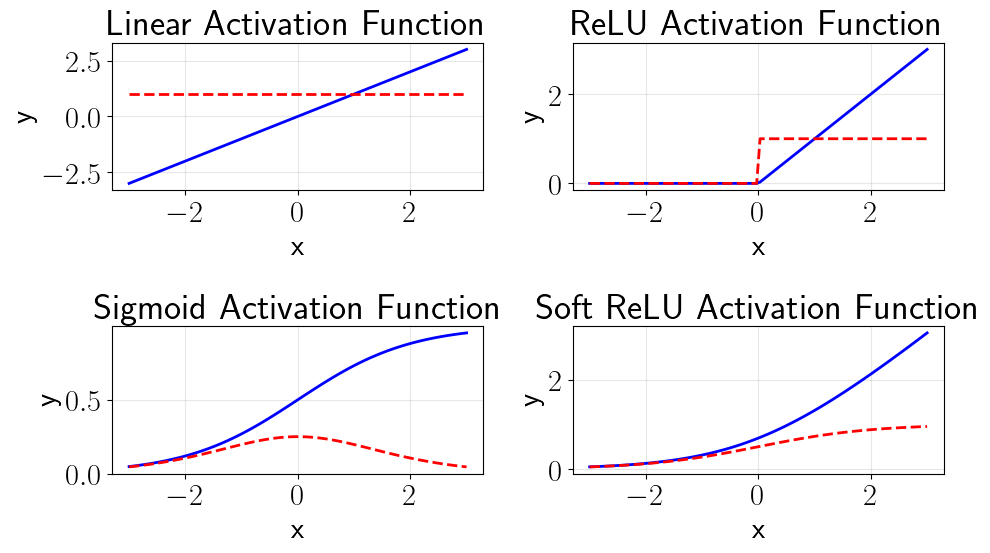

In [56]:
plt.figure(figsize=plot.big_wide_figsize)
for i, (name, activation) in enumerate(activations.items()):
    plt.subplot(2, 2, i+1)
    y = activation.forward(x)
    y_grad = activation.gradient(x)
    
    plt.plot(x, y, 'b-', linewidth=2, label=f'{name}(x)')
    plt.plot(x, y_grad, 'r--', linewidth=2, label=f"d{name}/dx")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'{name} Activation Function')
    plt.grid(True, alpha=0.3)

plt.tight_layout()

mlai.write_figure('activation-functions.svg', directory="./deepnn")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/activation-functions.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>Some different activation functions (solid line) and their
gradients (dashed line).</i>

$$\frac{\text{d}\mathbf{ f}_\ell}{\text{d}\boldsymbol{ \phi}_{\ell-1}} = \mathbf{W}_\ell$$

Then we have the *across layer* gradients $$
\frac{\text{d}\mathbf{ f}_\ell}{\text{d}\boldsymbol{ \phi}_{\ell-1}} = \mathbf{W}_\ell,
$$ which should be a $d_\ell\times d_{\ell-1}$ size matrix, which
matches the shape of $\mathbf{W}_\ell$.

$$\frac{\text{d} \mathbf{ f}_\ell}{\text{d}\mathbf{ w}_{\ell-k}} = \left[\prod_{i=0}^{k-1} \frac{\text{d} \mathbf{ f}_{\ell - i}}{\text{d} \boldsymbol{ \phi}_{\ell - i -1}}\frac{\text{d} \boldsymbol{ \phi}_{\ell - i -1}}{\text{d} \mathbf{ f}_{\ell - i -1}}\right] \frac{\text{d} \mathbf{ f}_{\ell-k}}{\text{d} \mathbf{ w}_{\ell - k}}$$

$$\frac{\text{d} \mathbf{ f}_\ell}{\text{d}\mathbf{ w}_{\ell-k}} = \left[\prod_{i=0}^{k-1} \mathbf{W}_{\ell - i} \boldsymbol{ \Phi}^\prime_{\ell - i -1}\right] \boldsymbol{ \phi}_{\ell-k-1}^\top \otimes \mathbf{I}_{d_{\ell-k}}$$

This now gives us the ability to compute the gradient of any
$\mathbf{W}_\ell$ in the model, $$
\frac{\text{d}
\mathbf{ f}_\ell}{\text{d}\mathbf{ w}_{\ell-k}} =
\left[\prod_{i=0}^{k-1} \frac{\text{d} \mathbf{ f}_{\ell - i}}{\text{d} \boldsymbol{ \phi}_{\ell - i -1}}\frac{\text{d} \boldsymbol{ \phi}_{\ell - i -1}}{\text{d} \mathbf{ f}_{\ell - i -1}}\right]
\frac{\text{d} \mathbf{ f}_{\ell-k}}{\text{d}
\mathbf{ w}_{\ell - k}}
$$ Substituting the matrix derivatives we derived: $$
\frac{\text{d}
\mathbf{ f}_\ell}{\text{d}\mathbf{ w}_{\ell-k}} =
\left[\prod_{i=0}^{k-1} \mathbf{W}_{\ell - i} \boldsymbol{ \Phi}^\prime_{\ell - i -1}\right]
\boldsymbol{ \phi}_{\ell-k-1}^\top \otimes \mathbf{I}_{d_{\ell-k}}
$$ where $\boldsymbol{ \Phi}^\prime_{\ell - i -1}$ is the derivative
matrix for the basis functions at layer $\ell - i -1$. This gives us the
complete gradient computation for any weight matrix in the network.

## Gradient Verification

In [57]:
from mlai import finite_difference_jacobian
import inspect
file_path = inspect.getfile(finite_difference_jacobian)

In [58]:
# %load -s finite_difference_jacobian /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
def finite_difference_jacobian(func, x, h=1e-5):
    """
    Compute Jacobian matrix using finite differences.
    
    This computes the Jacobian matrix of a vector-valued function
    using finite differences. Useful for testing neural network
    gradient computations.
    
    :param func: Vector-valued function to compute Jacobian for
    :type func: callable
    :param x: Point at which to compute Jacobian
    :type x: numpy.ndarray
    :param h: Step size for finite differences
    :type h: float
    :returns: Jacobian matrix (output_size × input_size)
    :rtype: numpy.ndarray
    
    Examples:
        >>> def f(x): return np.array([x[0]**2, x[1]**3])
        >>> x = np.array([2.0, 3.0])
        >>> jacobian = finite_difference_jacobian(f, x)
        >>> print(jacobian)  # Should be close to [[4, 0], [0, 27]]
    """
    x = np.asarray(x, dtype=float)
    output = func(x)
    output = np.asarray(output, dtype=float)
    
    # Initialize Jacobian matrix
    jacobian = np.zeros((output.size, x.size))
    
    # Compute gradient for each input dimension
    for i in range(x.size):
        # Create perturbation vectors
        x_plus = x.copy()
        x_minus = x.copy()
        
        # Perturb the i-th element
        x_plus.flat[i] += h
        x_minus.flat[i] -= h
        
        # Compute finite difference
        output_plus = func(x_plus)
        output_minus = func(x_minus)
        
        jacobian[:, i] = (output_plus - output_minus).flatten() / (2 * h)
    
    return jacobian


In [59]:
from mlai import verify_gradient_implementation
import inspect
file_path = inspect.getfile(verify_gradient_implementation)

In [60]:
# %load -s verify_gradient_implementation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
def verify_gradient_implementation(analytical_grad, numerical_grad, rtol=1e-5, atol=1e-8):
    """
    Verify that analytical gradient matches numerical gradient.
    
    This function compares analytical and numerical gradients to ensure
    the analytical implementation is correct. This is crucial for
    debugging gradient computations in neural networks.
    
    :param analytical_grad: Analytically computed gradient
    :type analytical_grad: numpy.ndarray
    :param numerical_grad: Numerically computed gradient
    :type numerical_grad: numpy.ndarray
    :param rtol: Relative tolerance for comparison
    :type rtol: float
    :param atol: Absolute tolerance for comparison
    :type atol: float
    :returns: True if gradients match within tolerance
    :rtype: bool
    
    Examples:
        >>> analytical = np.array([4.0, 6.0])
        >>> numerical = np.array([4.0001, 6.0001])
        >>> verify_gradient_implementation(analytical, numerical)
        True
    """
    try:
        np.testing.assert_allclose(analytical_grad, numerical_grad, rtol=rtol, atol=atol)
        return True
    except AssertionError:
        return False


In [61]:
import numpy as np

In [62]:
# Test data
x = np.array([1.0, -2.0, 0.5, -0.1])
results = {}

In [63]:
# Test Linear Activation
linear_activation = LinearActivation()
def linear_func(x):
    return linear_activation.forward(x)

numerical_grad = finite_difference_jacobian(linear_func, x)
analytical_grad = np.diag(linear_activation.gradient(x))
results['Linear'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Linear Activation: {'PASS' if results['Linear'] else 'FAIL'}")

Linear Activation: PASS


In [64]:
# Test ReLU Activation
relu_activation = ReLUActivation()
def relu_func(x):
    return relu_activation.forward(x)

numerical_grad = finite_difference_jacobian(relu_func, x)
analytical_grad = np.diag(relu_activation.gradient(x))
results['ReLU'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"ReLU Activation: {'PASS' if results['ReLU'] else 'FAIL'}")

ReLU Activation: PASS


In [65]:
# Test Sigmoid Activation
sigmoid_activation = SigmoidActivation()
def sigmoid_func(x):
    return sigmoid_activation.forward(x)

numerical_grad = finite_difference_jacobian(sigmoid_func, x)
analytical_grad = np.diag(sigmoid_activation.gradient(x))
results['Sigmoid'] = verify_gradient_implementation(analytical_grad, 
numerical_grad)
print(f"Sigmoid Activation: {'PASS' if results['Sigmoid'] else 'FAIL'}")

Sigmoid Activation: PASS


In [66]:
# Test Soft ReLU Activation
soft_relu_activation = SoftReLUActivation()
def soft_relu_func(x):
    return soft_relu_activation.forward(x)

numerical_grad = finite_difference_jacobian(soft_relu_func, x)
analytical_grad = np.diag(soft_relu_activation.gradient(x))
results['SoftReLU'] = verify_gradient_implementation(analytical_grad, 
numerical_grad)
print(f"Soft ReLU Activation: {'PASS' if results['SoftReLU'] else 'FAIL'}")

Soft ReLU Activation: PASS


## Verify Neural Network Gradients

Testing neural network gradients with finite differences

In [67]:
results = {}

In [68]:
# Test 1: Simple linear network
print("\nTesting simple linear network...")
dimensions = [2, 2, 1]
activations = [LinearActivation(), LinearActivation()]

# Create network
network = NeuralNetwork(dimensions, activations)
x = np.array([[1.0, 2.0]])

# Forward pass to populate z and a attributes
network.predict(x)

# Test gradient with respect to first weight matrix
def network_output_w0(w0_flat):
    w0 = w0_flat.reshape(network.weights[0].shape)
    test_network = NeuralNetwork(dimensions, activations)
    test_network.weights[0] = w0
    test_network.biases[0] = network.biases[0]
    test_network.weights[1] = network.weights[1]
    test_network.biases[1] = network.biases[1]
    return test_network.predict(x).flatten()

w0_flat = network.weights[0].flatten()
numerical_grad = finite_difference_jacobian(network_output_w0, w0_flat).flatten()

output_gradient = np.array([[1.0]])
analytical_grad = network.compute_gradient_for_layer(0, output_gradient).flatten()

results['Linear_Network'] = verify_gradient_implementation(analytical_grad, 
numerical_grad, rtol=1e-4)
print(f"Linear Network: {'PASS' if results['Linear_Network'] else 'FAIL'}")


Testing simple linear network...
Linear Network: PASS


In [69]:
# Test 2: Network with ReLU activation
print("\nTesting network with ReLU activation...")
dimensions = [2, 3, 1]
activations = [ReLUActivation(), LinearActivation()]
network = NeuralNetwork(dimensions, activations)

# Forward pass to populate z and a attributes
network.predict(x)

def network_output_w0_relu(w0_flat):
    w0 = w0_flat.reshape(network.weights[0].shape)
    test_network = NeuralNetwork(dimensions, activations)
    test_network.weights[0] = w0
    test_network.biases[0] = network.biases[0]
    test_network.weights[1] = network.weights[1]
    test_network.biases[1] = network.biases[1]
    return test_network.predict(x).flatten()

w0_flat = network.weights[0].flatten()
numerical_grad = finite_difference_jacobian(network_output_w0_relu, w0_flat).flatten()

analytical_grad = network.compute_gradient_for_layer(0, output_gradient).flatten()

results['ReLU_Network'] = verify_gradient_implementation(analytical_grad, 
numerical_grad, rtol=1e-4)
print(f"ReLU Network: {'PASS' if results['ReLU_Network'] else 'FAIL'}")


Testing network with ReLU activation...
ReLU Network: PASS


In [70]:
# Test Network with sigmoid activation
print("\nTesting network with sigmoid activation...")
dimensions = [2, 3, 1]
activations = [SigmoidActivation(), LinearActivation()]
network = NeuralNetwork(dimensions, activations)

# Forward pass to populate z and a attributes
network.predict(x)

def network_output_w0_sigmoid(w0_flat):
    w0 = w0_flat.reshape(network.weights[0].shape)
    test_network = NeuralNetwork(dimensions, activations)
    test_network.weights[0] = w0
    test_network.biases[0] = network.biases[0]
    test_network.weights[1] = network.weights[1]
    test_network.biases[1] = network.biases[1]
    return test_network.predict(x).flatten()

w0_flat = network.weights[0].flatten()
numerical_grad = finite_difference_jacobian(network_output_w0_sigmoid, w0_flat).flatten()

analytical_grad = network.compute_gradient_for_layer(0, output_gradient).flatten()

results['Sigmoid_Network'] = verify_gradient_implementation(analytical_grad, 
numerical_grad, rtol=1e-4)
print(f"Sigmoid Network: {'PASS' if results['Sigmoid_Network'] else 'FAIL'}")


Testing network with sigmoid activation...
Sigmoid Network: PASS


## Loss Functions

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/loss-functions.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/loss-functions.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [71]:
from mlai import MeanSquaredError
import inspect
file_path = inspect.getfile(MeanSquaredError)

In [72]:
# %load -s MeanSquaredError /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class MeanSquaredError(LossFunction):
    """
    Mean Squared Error loss function.
    
    This loss function is commonly used for regression problems.
    It computes the average of the squared differences between
    predictions and targets.
    
    Mathematical formulation:
    MSE = (1/n) * Σ(y_pred - y_true)²
    
    The gradient is: dMSE/dy_pred = (2/n) * (y_pred - y_true)
    
    Examples:
        >>> loss = MeanSquaredError()
        >>> y_pred = np.array([[1.0], [2.0], [3.0]])
        >>> y_true = np.array([[1.1], [1.9], [3.1]])
        >>> loss_value = loss.forward(y_pred, y_true)
        >>> gradient = loss.gradient(y_pred, y_true)
    """
    def __init__(self):
        super().__init__()
        self.name = "Mean Squared Error"
    
    def forward(self, predictions, targets):
        """
        Compute the mean squared error.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Mean squared error
        :rtype: float
        """
        return np.mean((predictions - targets) ** 2)
    
    def gradient(self, predictions, targets):
        """
        Compute the gradient of MSE with respect to predictions.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Gradient of MSE with respect to predictions
        :rtype: numpy.ndarray
        """
        return (2.0 / predictions.size) * (predictions - targets)


In [73]:
from mlai import MeanAbsoluteError
import inspect
file_path = inspect.getfile(MeanAbsoluteError)

In [74]:
# %load -s MeanAbsoluteError /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class MeanAbsoluteError(LossFunction):
    """
    Mean Absolute Error loss function.
    
    This loss function is used for regression problems and is more
    robust to outliers than mean squared error.
    
    Mathematical formulation:
    MAE = (1/n) * Σ|y_pred - y_true|
    
    The gradient is: dMAE/dy_pred = (1/n) * sign(y_pred - y_true)
    
    Examples:
        >>> loss = MeanAbsoluteError()
        >>> y_pred = np.array([[1.0], [2.0], [3.0]])
        >>> y_true = np.array([[1.1], [1.9], [3.1]])
        >>> loss_value = loss.forward(y_pred, y_true)
        >>> gradient = loss.gradient(y_pred, y_true)
    """
    def __init__(self):
        super().__init__()
        self.name = "Mean Absolute Error"
    
    def forward(self, predictions, targets):
        """
        Compute the mean absolute error.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Mean absolute error
        :rtype: float
        """
        return np.mean(np.abs(predictions - targets))
    
    def gradient(self, predictions, targets):
        """
        Compute the gradient of MAE with respect to predictions.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Gradient of MAE with respect to predictions
        :rtype: numpy.ndarray
        """
        return np.sign(predictions - targets) / predictions.size


In [75]:
from mlai import BinaryCrossEntropyLoss
import inspect
file_path = inspect.getfile(BinaryCrossEntropyLoss)

In [76]:
# %load -s BinaryCrossEntropyLoss /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class BinaryCrossEntropyLoss(LossFunction):
    """
    Binary cross-entropy loss function for binary classification.
    
    This loss function is used for binary classification problems
    where the output is a single probability value.
    
    Mathematical formulation:
    BCE = -[y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred)]
    
    The gradient is: dBCE/dy_pred = -(y_true / y_pred - (1 - y_true) / (1 - y_pred))
    
    Examples:
        >>> loss = BinaryCrossEntropyLoss()
        >>> y_pred = np.array([[0.8], [0.3], [0.9]])
        >>> y_true = np.array([[1.0], [0.0], [1.0]])
        >>> loss_value = loss.forward(y_pred, y_true)
        >>> gradient = loss.gradient(y_pred, y_true)
    """
    def __init__(self, epsilon=1e-15):
        """
        Initialize binary cross-entropy loss.
        
        :param epsilon: Small value to prevent log(0)
        :type epsilon: float
        """
        super().__init__()
        self.epsilon = epsilon
        self.name = "Binary Cross Entropy"
    
    def forward(self, predictions, targets):
        """
        Compute the binary cross-entropy loss.
        
        :param predictions: Model predictions (probabilities), shape (n_samples, 1)
        :type predictions: numpy.ndarray
        :param targets: True target values (0 or 1), shape (n_samples, 1)
        :type targets: numpy.ndarray
        :returns: Binary cross-entropy loss
        :rtype: float
        """
        # Clip predictions to prevent log(0)
        predictions = np.clip(predictions, self.epsilon, 1.0 - self.epsilon)
        return -np.mean(targets * np.log(predictions) + (1 - targets) * np.log(1 - predictions))
    
    def gradient(self, predictions, targets):
        """
        Compute the gradient of binary cross-entropy with respect to predictions.
        
        :param predictions: Model predictions (probabilities), shape (n_samples, 1)
        :type predictions: numpy.ndarray
        :param targets: True target values (0 or 1), shape (n_samples, 1)
        :type targets: numpy.ndarray
        :returns: Gradient of binary cross-entropy with respect to predictions
        :rtype: numpy.ndarray
        """
        # Clip predictions to prevent division by zero
        predictions = np.clip(predictions, self.epsilon, 1.0 - self.epsilon)
        return -(targets / predictions - (1 - targets) / (1 - predictions)) / predictions.shape[0]


In [77]:
import numpy as np

In [78]:
y_pred = np.array([[0.8], [0.3], [0.9], [0.1]])
y_true = np.array([[1.0], [0.0], [1.0], [0.0]])

losses = {
    'MSE': MeanSquaredError(),
    'MAE': MeanAbsoluteError(),
    'BCE': BinaryCrossEntropyLoss()
}

print("Loss Function Demonstration:")
print(f"Predictions: {y_pred.flatten()}")
print(f"True values: {y_true.flatten()}")
print()

for name, loss in losses.items():
    loss_value = loss.forward(y_pred, y_true)
    gradient = loss.gradient(y_pred, y_true)
    print(f"{name:3}: Loss = {loss_value:.4f}, Gradient = {gradient.flatten()}")

Loss Function Demonstration:
Predictions: [0.8 0.3 0.9 0.1]
True values: [1. 0. 1. 0.]

MSE: Loss = 0.0375, Gradient = [-0.1   0.15 -0.05  0.05]
MAE: Loss = 0.1750, Gradient = [-0.25  0.25 -0.25  0.25]
BCE: Loss = 0.1976, Gradient = [-0.3125      0.35714286 -0.27777778  0.27777778]


## Test loss function gradients

Testing loss function gradients with finite differences.

In [79]:
from mlai import finite_difference_jacobian
import inspect
file_path = inspect.getfile(finite_difference_jacobian)

In [80]:
# %load -s finite_difference_jacobian /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
def finite_difference_jacobian(func, x, h=1e-5):
    """
    Compute Jacobian matrix using finite differences.
    
    This computes the Jacobian matrix of a vector-valued function
    using finite differences. Useful for testing neural network
    gradient computations.
    
    :param func: Vector-valued function to compute Jacobian for
    :type func: callable
    :param x: Point at which to compute Jacobian
    :type x: numpy.ndarray
    :param h: Step size for finite differences
    :type h: float
    :returns: Jacobian matrix (output_size × input_size)
    :rtype: numpy.ndarray
    
    Examples:
        >>> def f(x): return np.array([x[0]**2, x[1]**3])
        >>> x = np.array([2.0, 3.0])
        >>> jacobian = finite_difference_jacobian(f, x)
        >>> print(jacobian)  # Should be close to [[4, 0], [0, 27]]
    """
    x = np.asarray(x, dtype=float)
    output = func(x)
    output = np.asarray(output, dtype=float)
    
    # Initialize Jacobian matrix
    jacobian = np.zeros((output.size, x.size))
    
    # Compute gradient for each input dimension
    for i in range(x.size):
        # Create perturbation vectors
        x_plus = x.copy()
        x_minus = x.copy()
        
        # Perturb the i-th element
        x_plus.flat[i] += h
        x_minus.flat[i] -= h
        
        # Compute finite difference
        output_plus = func(x_plus)
        output_minus = func(x_minus)
        
        jacobian[:, i] = (output_plus - output_minus).flatten() / (2 * h)
    
    return jacobian


In [81]:
from mlai import verify_gradient_implementation
import inspect
file_path = inspect.getfile(verify_gradient_implementation)

In [82]:
# %load -s verify_gradient_implementation /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
def verify_gradient_implementation(analytical_grad, numerical_grad, rtol=1e-5, atol=1e-8):
    """
    Verify that analytical gradient matches numerical gradient.
    
    This function compares analytical and numerical gradients to ensure
    the analytical implementation is correct. This is crucial for
    debugging gradient computations in neural networks.
    
    :param analytical_grad: Analytically computed gradient
    :type analytical_grad: numpy.ndarray
    :param numerical_grad: Numerically computed gradient
    :type numerical_grad: numpy.ndarray
    :param rtol: Relative tolerance for comparison
    :type rtol: float
    :param atol: Absolute tolerance for comparison
    :type atol: float
    :returns: True if gradients match within tolerance
    :rtype: bool
    
    Examples:
        >>> analytical = np.array([4.0, 6.0])
        >>> numerical = np.array([4.0001, 6.0001])
        >>> verify_gradient_implementation(analytical, numerical)
        True
    """
    try:
        np.testing.assert_allclose(analytical_grad, numerical_grad, rtol=rtol, atol=atol)
        return True
    except AssertionError:
        return False


In [83]:
# Test data
y_pred = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
y_true = np.array([[1.1, 2.1], [2.9, 4.1], [5.1, 5.9]])

results = {}

In [84]:
# Test Mean Squared Error
mse_loss = MeanSquaredError()
def mse_func(pred):
    return mse_loss.forward(pred.reshape(y_pred.shape), y_true)

numerical_grad = finite_difference_jacobian(mse_func, y_pred.flatten()).flatten()
analytical_grad = mse_loss.gradient(y_pred, y_true).flatten()
results['MSE'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Mean Squared Error: {'PASS' if results['MSE'] else 'FAIL'}")

Mean Squared Error: PASS


In [85]:
# Test Mean Absolute Error
mae_loss = MeanAbsoluteError()
def mae_func(pred):
    return mae_loss.forward(pred.reshape(y_pred.shape), y_true)

numerical_grad = finite_difference_jacobian(mae_func, y_pred.flatten()).flatten()
analytical_grad = mae_loss.gradient(y_pred, y_true).flatten()
results['MAE'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Mean Absolute Error: {'PASS' if results['MAE'] else 'FAIL'}")

Mean Absolute Error: PASS


In [86]:
from mlai import HuberLoss
import inspect
file_path = inspect.getfile(HuberLoss)

In [87]:
# %load -s HuberLoss /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class HuberLoss(LossFunction):
    """
    Huber loss function (smooth L1 loss).
    
    This loss function combines the benefits of mean squared error
    and mean absolute error. It's quadratic for small errors and
    linear for large errors, making it robust to outliers.
    
    Mathematical formulation:
    Huber = (1/n) * Σ L_δ(y_pred - y_true)
    where L_δ(a) = 0.5 * a² if |a| ≤ δ, else δ * (|a| - 0.5 * δ)
    
    Examples:
        >>> loss = HuberLoss(delta=1.0)
        >>> y_pred = np.array([[1.0], [2.0], [3.0]])
        >>> y_true = np.array([[1.1], [1.9], [3.1]])
        >>> loss_value = loss.forward(y_pred, y_true)
        >>> gradient = loss.gradient(y_pred, y_true)
    """
    def __init__(self, delta=1.0):
        """
        Initialize Huber loss.
        
        :param delta: Threshold parameter
        :type delta: float
        """
        super().__init__()
        self.delta = delta
        self.name = f"Huber Loss (δ={delta})"
    
    def forward(self, predictions, targets):
        """
        Compute the Huber loss.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Huber loss
        :rtype: float
        """
        error = predictions - targets
        abs_error = np.abs(error)
        
        # Quadratic part for small errors
        quadratic = 0.5 * error ** 2
        # Linear part for large errors
        linear = self.delta * (abs_error - 0.5 * self.delta)
        
        return np.mean(np.where(abs_error <= self.delta, quadratic, linear))
    
    def gradient(self, predictions, targets):
        """
        Compute the gradient of Huber loss with respect to predictions.
        
        :param predictions: Model predictions, shape (n_samples, n_outputs)
        :type predictions: numpy.ndarray
        :param targets: True target values, shape (n_samples, n_outputs)
        :type targets: numpy.ndarray
        :returns: Gradient of Huber loss with respect to predictions
        :rtype: numpy.ndarray
        """
        error = predictions - targets
        abs_error = np.abs(error)
        
        # Gradient is error for small errors, sign(error) * delta for large errors
        gradient = np.where(abs_error <= self.delta, error, self.delta * np.sign(error))
        
        return gradient / predictions.size


In [88]:
# Test Huber Loss
huber_loss = HuberLoss(delta=1.0)
def huber_func(pred):
    return huber_loss.forward(pred.reshape(y_pred.shape), y_true)

numerical_grad = finite_difference_jacobian(huber_func, y_pred.flatten()).flatten()
analytical_grad = huber_loss.gradient(y_pred, y_true).flatten()
results['Huber'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Huber Loss: {'PASS' if results['Huber'] else 'FAIL'}")

Huber Loss: PASS


In [89]:
# Test Binary Cross Entropy
bce_loss = BinaryCrossEntropyLoss()
y_pred_bce = np.array([[0.8], [0.3], [0.9]])
y_true_bce = np.array([[1.0], [0.0], [1.0]])

def bce_func(pred):
    return bce_loss.forward(pred.reshape(-1, 1), y_true_bce)

numerical_grad = finite_difference_jacobian(bce_func, y_pred_bce.flatten()).flatten()
analytical_grad = bce_loss.gradient(y_pred_bce, y_true_bce).flatten()
results['BCE'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Binary Cross Entropy: {'PASS' if results['BCE'] else 'FAIL'}")

Binary Cross Entropy: PASS


In [90]:
from mlai import CrossEntropyLoss
import inspect
file_path = inspect.getfile(CrossEntropyLoss)

In [91]:
# %load -s CrossEntropyLoss /opt/anaconda3/envs/py311/lib/python3.11/site-packages/mlai/mlai.py
class CrossEntropyLoss(LossFunction):
    """
    Cross-entropy loss function for classification.
    
    This loss function is commonly used for multi-class classification
    problems. It measures the difference between predicted class
    probabilities and true class labels.
    
    Mathematical formulation:
    CE = -Σ y_true * log(y_pred)
    
    The gradient is: dCE/dy_pred = -y_true / y_pred
    
    Examples:
        >>> loss = CrossEntropyLoss()
        >>> y_pred = np.array([[0.1, 0.9], [0.8, 0.2]])
        >>> y_true = np.array([[0, 1], [1, 0]])
        >>> loss_value = loss.forward(y_pred, y_true)
        >>> gradient = loss.gradient(y_pred, y_true)
    """
    def __init__(self, epsilon=1e-15):
        """
        Initialize cross-entropy loss.
        
        :param epsilon: Small value to prevent log(0)
        :type epsilon: float
        """
        super().__init__()
        self.epsilon = epsilon
        self.name = "Cross Entropy"
    
    def forward(self, predictions, targets):
        """
        Compute the cross-entropy loss.
        
        :param predictions: Model predictions (probabilities), shape (n_samples, n_classes)
        :type predictions: numpy.ndarray
        :param targets: True target values (one-hot encoded), shape (n_samples, n_classes)
        :type targets: numpy.ndarray
        :returns: Cross-entropy loss
        :rtype: float
        """
        # Clip predictions to prevent log(0)
        predictions = np.clip(predictions, self.epsilon, 1.0 - self.epsilon)
        return -np.mean(np.sum(targets * np.log(predictions), axis=1))
    
    def gradient(self, predictions, targets):
        """
        Compute the gradient of cross-entropy with respect to predictions.
        
        :param predictions: Model predictions (probabilities), shape (n_samples, n_classes)
        :type predictions: numpy.ndarray
        :param targets: True target values (one-hot encoded), shape (n_samples, n_classes)
        :type targets: numpy.ndarray
        :returns: Gradient of cross-entropy with respect to predictions
        :rtype: numpy.ndarray
        """
        # Clip predictions to prevent division by zero
        predictions = np.clip(predictions, self.epsilon, 1.0 - self.epsilon)
        return -targets / (predictions * predictions.shape[0])


In [92]:
# Test Cross Entropy
ce_loss = CrossEntropyLoss()
y_pred_ce = np.array([[0.1, 0.9], [0.8, 0.2], [0.3, 0.7]])
y_true_ce = np.array([[0, 1], [1, 0], [0, 1]])

def ce_func(pred):
    return ce_loss.forward(pred.reshape(-1, 2), y_true_ce)

numerical_grad = finite_difference_jacobian(ce_func, y_pred_ce.flatten()).flatten()
analytical_grad = ce_loss.gradient(y_pred_ce, y_true_ce).flatten()
results['CE'] = verify_gradient_implementation(analytical_grad, numerical_grad)
print(f"Cross Entropy: {'PASS' if results['CE'] else 'FAIL'}")

Cross Entropy: PASS


## Simple Deep NN Implementation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/simple-deep-nn-implementation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/simple-deep-nn-implementation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In [93]:
def create_synthetic_data(n_samples=100, task='regression'):
    """Create synthetic datasets for demonstration."""
    np.random.seed(42)
    
    if task == 'regression':
        # Non-linear regression: y = x1^2 + x2^2 + noise
        X = np.random.randn(n_samples, 2)
        y = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1) + 0.1 * np.random.randn(n_samples, 1)
        return X, y
    
    elif task == 'classification':
        # Binary classification: x1^2 + x2^2 > 1
        X = np.random.randn(n_samples, 2)
        y = ((X[:, 0]**2 + X[:, 1]**2) > 1.0).astype(float).reshape(-1, 1)
        return X, y

# Create data

X_reg, y_reg = create_synthetic_data(200, ‘regression’) X_cls, y_cls =
create_synthetic_data(200, ‘classification’)

print(f“Regression data: {X_reg.shape} -\> {y_reg.shape}”)
print(f“Classification data: {X_cls.shape} -\> {y_cls.shape}”)

## Create and Test Neural Network

In [94]:
from mlai import ReLUActivation, LinearActivation, NeuralNetwork

In [95]:
dimensions = [2, 5, 1]  # 2 inputs, 1 hidden layer (5 neurons), 1 output
activations = [ReLUActivation(), LinearActivation()]
network = NeuralNetwork(dimensions, activations)

# Test forward pass
X_test = np.array([[1.0, 2.0], [3.0, 4.0]])
y_pred = network.predict(X_test)

print("Neural Network Test:")
print(f"Input: {X_test}")
print(f"Output: {y_pred.flatten()}")
print(f"Network architecture: {dimensions}")
print(f"Number of parameters: {sum(w.size for w in network.weights) + sum(b.size for b in network.biases)}")

Neural Network Test:
Input: [[1. 2.]
 [3. 4.]]
Output: [0.91338547 1.80225009]
Network architecture: [2, 5, 1]
Number of parameters: 21


## Test Backpopagation

In [96]:
# Forward pass
y_pred = network.predict(X_test)
loss_fn = MeanSquaredError()
y_true = np.array([[1.0], [2.0]])

# Compute loss and gradient
loss_value = loss_fn.forward(y_pred, y_true)
loss_gradient = loss_fn.gradient(y_pred, y_true)

# Backward pass
gradients = network.backward(loss_gradient)

print("Backpropagation Test:")
print(f"Loss value: {loss_value:.4f}")
print(f"Loss gradient: {loss_gradient.flatten()}")
print(f"Weight gradients shapes: {[g.shape for g in gradients['weight_gradients']]}")
print(f"Bias gradients shapes: {[g.shape for g in gradients['bias_gradients']]}")

Backpropagation Test:
Loss value: 0.0233
Loss gradient: [-0.08661453 -0.19774991]
Weight gradients shapes: [(2, 5), (5, 1)]
Bias gradients shapes: [(5,), (1,)]


## Train Network for Regression

In [97]:
def train_network_regression(X, y, n_epochs=50, learning_rate=0.01):
    """Train a neural network for regression."""
    # Create network
    dimensions = [2, 10, 10, 1]
    activations = [ReLUActivation(), ReLUActivation(), LinearActivation()]
    network = NeuralNetwork(dimensions, activations)
    
    # Loss function
    loss_fn = MeanSquaredError()
    
    # Training loop
    losses = []
    for epoch in range(n_epochs):
        # Forward pass
        y_pred = network.predict(X)
        loss = loss_fn.forward(y_pred, y)
        
        # Backward pass
        loss_gradient = loss_fn.gradient(y_pred, y)
        gradients = network.backward(loss_gradient)
        
        # Update weights (simple gradient descent)
        for i in range(len(network.weights)):
            network.weights[i] -= learning_rate * gradients['weight_gradients'][i]
            network.biases[i] -= learning_rate * gradients['bias_gradients'][i]
        
        losses.append(loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: Loss = {loss:.4f}")
    
    return network, losses

In [98]:
X_reg, y_reg = create_synthetic_data(200, 'regression')
network_reg, losses = train_network_regression(X_reg, y_reg)

Epoch   0: Loss = 45.6138
Epoch  10: Loss = 3.1425
Epoch  20: Loss = 2.5951
Epoch  30: Loss = 2.2159
Epoch  40: Loss = 1.8836


In [99]:
import matplotlib.pyplot as plt
import mlai.plot

Final training loss: 1.6131


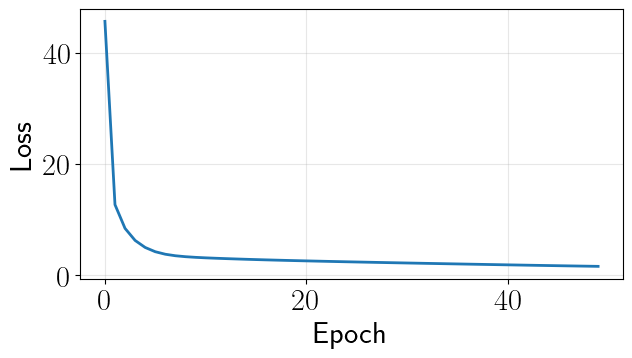

In [100]:
fig, ax = plt.subplots(figsize=plot.wide_figsize)
ax.plot(losses, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.grid(True, alpha=0.3)

print(f"Final training loss: {losses[-1]:.4f}")

mlai.write_figure(“nn-regression-training-progress.svg,”
directory=“./ml”) }

Figure: <i></i>{\<img
src=“https://mlatcl.github.io/mlfc/./slides/diagrams//ml/nn-regression-trainng-progress.”svg"
class="" width=“50%” style=“vertical-align:middle;”\>}{Neural Network
Training Progress for a regression
model){nn-regression-training-progress}

In [116]:
def train_network_classification(X, y, n_epochs=500, learning_rate=0.1):
    """Train a neural network for classification."""
    # Create network
    dimensions = [2, 8, 8, 8, 8, 8, 8, 1]
    activations = [ReLUActivation(), ReLUActivation(), ReLUActivation(), ReLUActivation(), SigmoidActivation(), ReLUActivation(), SigmoidActivation()]  # Sigmoid for binary classification
    network = NeuralNetwork(dimensions, activations)
    
    # Loss function
    loss_fn = BinaryCrossEntropyLoss()
    
    # Training loop
    losses = []
    accuracies = []
    
    for epoch in range(n_epochs):
        # Forward pass
        y_pred = network.predict(X)
        loss = loss_fn.forward(y_pred, y)
        
        # Backward pass
        loss_gradient = loss_fn.gradient(y_pred, y)
        gradients = network.backward(loss_gradient)
        
        # Update weights
        for i in range(len(network.weights)):
            network.weights[i] -= learning_rate * gradients['weight_gradients'][i]
            network.biases[i] -= learning_rate * gradients['bias_gradients'][i]
        
        # Calculate accuracy
        predictions = (y_pred > 0.5).astype(float)
        accuracy = np.mean(predictions == y)
        
        losses.append(loss)
        accuracies.append(accuracy)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: Loss = {loss:.4f}, Accuracy = {accuracy:.4f}")
    
    return network, losses, accuracies

In [117]:
X_cls, y_cls = create_synthetic_data(200, 'classification')
network_cls, losses_cls, accuracies = train_network_classification(X_cls, y_cls)

Epoch   0: Loss = 0.7642, Accuracy = 0.5600
Epoch  10: Loss = 0.6836, Accuracy = 0.5600
Epoch  20: Loss = 0.6757, Accuracy = 0.5600
Epoch  30: Loss = 0.6716, Accuracy = 0.5600
Epoch  40: Loss = 0.6671, Accuracy = 0.5600
Epoch  50: Loss = 0.6621, Accuracy = 0.5600
Epoch  60: Loss = 0.6562, Accuracy = 0.5600
Epoch  70: Loss = 0.6490, Accuracy = 0.5600
Epoch  80: Loss = 0.6398, Accuracy = 0.5600
Epoch  90: Loss = 0.6278, Accuracy = 0.5600
Epoch 100: Loss = 0.6125, Accuracy = 0.6300
Epoch 110: Loss = 0.5915, Accuracy = 0.7550
Epoch 120: Loss = 0.5655, Accuracy = 0.7800
Epoch 130: Loss = 0.5340, Accuracy = 0.8250
Epoch 140: Loss = 0.4969, Accuracy = 0.8200
Epoch 150: Loss = 0.4557, Accuracy = 0.8600
Epoch 160: Loss = 0.4097, Accuracy = 0.8800
Epoch 170: Loss = 0.3719, Accuracy = 0.8800
Epoch 180: Loss = 0.4384, Accuracy = 0.7750
Epoch 190: Loss = 0.4194, Accuracy = 0.7850
Epoch 200: Loss = 0.4005, Accuracy = 0.7950
Epoch 210: Loss = 0.3850, Accuracy = 0.8150
Epoch 220: Loss = 0.3736, Accura

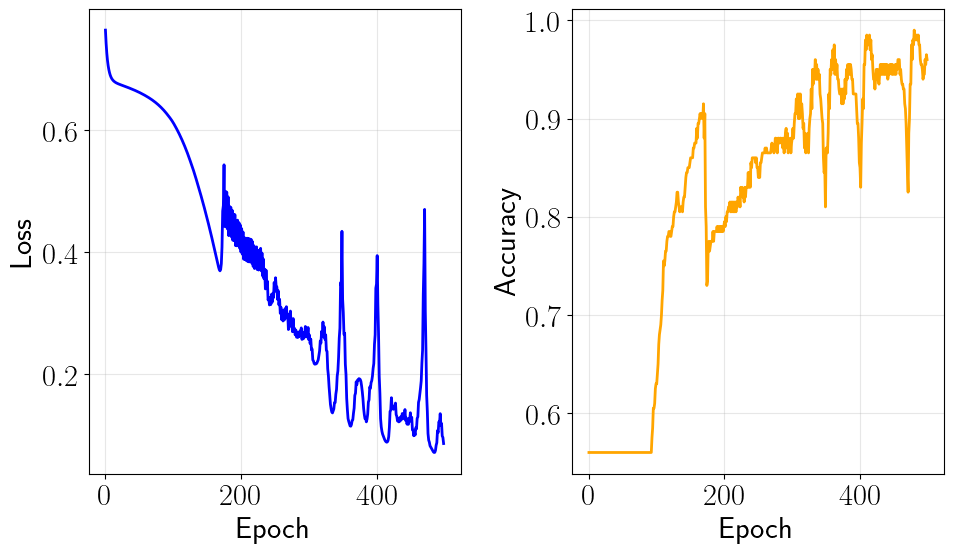

Final training loss: 0.0868
Final training accuracy: 0.9600


<Figure size 640x480 with 0 Axes>

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=plot.big_wide_figsize)

ax1.plot(losses_cls, linewidth=2, color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(accuracies, linewidth=2, color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {losses_cls[-1]:.4f}")
print(f"Final training accuracy: {accuracies[-1]:.4f}")
mlai.write_figure("classification-training.svg", directory="./deepnn/")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/classification-training.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>Training error for the fitting of the neural network. Left is
training loss, right is training accuracy</i>

## Visualise Decision Boundary

In [113]:
import mlai.plot
import numpy as np
import matplotlib.pyplot as plt
import mlai

In [114]:
def plot_decision_boundary(network, X, y, filename="neural-network-decision.svg", directory="../diagrams"):
    """Plot the decision boundary of a trained neural network."""
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Make predictions on mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = network.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.subplots(figsize=plot.big_figsize)
    plt.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdYlBu')
    plt.colorbar(label='Prediction')
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='RdYlBu', 
                         edgecolors='black', linewidth=1)
    plt.colorbar(scatter, label='True Label')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    
    mlai.write_figure(filename, directory=directory)

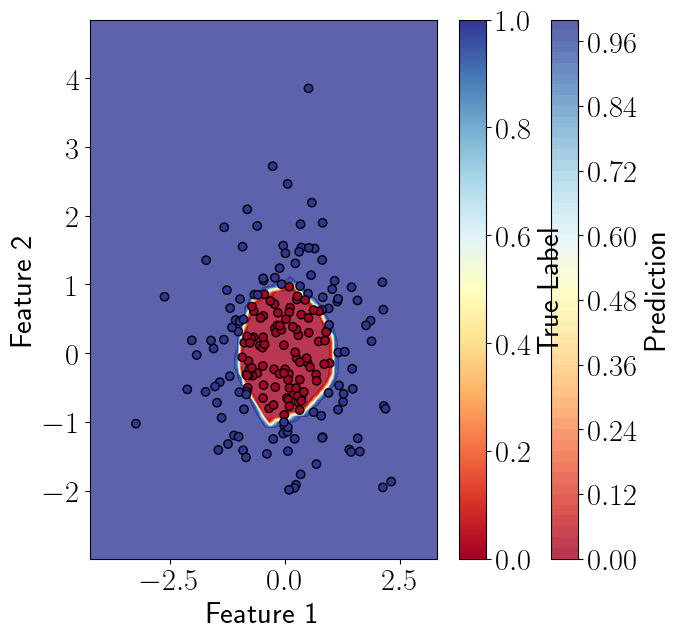

In [115]:
plot_decision_boundary(network_cls, X_cls, y_cls, "neural-network-decision-boundary.svg", directory="./deepnn/")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//deepnn/neural-network-decision-boundary.svg" class="" width="50%" style="vertical-align:middle;">

Figure: <i>Decision boundary for the trained neural network</i>

## Evaluating Derivatives

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_ml/includes/automatic-differentiation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_ml/includes/automatic-differentiation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

See also the presentation by Ferenc Huszár on the Deep Neural Network
course at the University of Cambridge. Ferenc’s original slides [are
here](https://hackmd.io/@fhuszar/H1WZ70kl_#) and his notes on
approximating with ReLU are
[here](https://hackmd.io/@fhuszar/S1UdOvZe_). His notes on automatic
differentiation [are here](https://hackmd.io/@fhuszar/SyHTInWeu). His
Google colab notebook is
[here](https://colab.research.google.com/drive/1qioPLq-dxOwudPKXU3MxpHr2s4Su3dxI?usp=sharing).
He also recommended a review paper from
[JMLR](https://jmlr.org/papers/v18/17-468.html) Baydin et al. (2018)
(See Figure 2).

The chain of matrix multiplications gives us a choice about how we
evaluate this system. If we want to take the derivative of the ouptut
function with respect to the weights we need to compute the chain rule.
$$
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}} \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

$$
\small
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \left( \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}} \left( \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \cdots \left( \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \left( \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} \right) \right) \cdots \right) \right)
$$

## Or like this?

$$
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}} \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

$$
\small
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \left( \left( \cdots \left( \left( \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}}  \right) \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \right) \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \right) \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \right) \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

## Or in a funky way?

$$
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}} \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

$$
\small
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \left( \left( \left( \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}}  \right) \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \right) \left( \left( \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \right) \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \right) \right)\frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

## Automatic differentiation

*Forward-mode*

$$
\small
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \left( \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}} \left( \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \cdots \left( \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \left( \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} \right) \right) \cdots \right) \right)
$$

Cost: $$
\small
d_0 d_1 d_2 + d_0 d_2 d_3 + \ldots + d_0 d_{L-1} d_L= d_0 \sum_{\ell=2}^{L} d_\ell d_{\ell-1}
$$

*Reverse-mode*

$$
\small
\frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ w}} = \left( \left( \cdots \left( \left( \frac{\text{d} \mathbf{ f}_L}{\text{d} \mathbf{ f}_{L-1}} \frac{\text{d} \mathbf{ f}_{L-1}}{\text{d} \mathbf{ f}_{L-2}}  \right) \frac{\text{d} \mathbf{ f}_{L-2}}{\text{d} \mathbf{ f}_{L-3}} \right) \cdots \frac{\text{d} \mathbf{ f}_3}{\text{d} \mathbf{ f}_{2}} \right) \frac{\text{d} \mathbf{ f}_2}{\text{d} \mathbf{ f}_{1}} \right) \frac{\text{d} \mathbf{ f}_1}{\text{d} \mathbf{ w}} 
$$

Cost: $$
\small
 d_Ld_{L-1}d_{L-2} + d_{L}d_{L-2} d_{L-3} + \ldots + d_Ld_{1} d_0 = d_L\sum_{\ell=0}^{L-2}d_\ell d_{\ell+1}
$$

## Memory cost of autodiff

Let $d_l$ denote the output dimensionality at layer $l$. Jacobians are
evaluated at intermediate activations $\mathbf{ f}_l$.

### Forward-mode

Placeholder figure: forward-mode memory footprint (streaming through
layers).

### Reverse-mode

Placeholder figure: reverse-mode memory footprint (cached activations
reused in backward).

## Automatic differentiation

-   in deep learning we’re most interested in scalar objectives
-   $d_L=1$, consequently, backward mode is always optimal
-   in the context of neural networks this is *backpropagation*.
-   backprop has higher memory cost than forwardprop

### Backprop in deep networks

For gradients of scalar objectives ($d_L=1$), reverse-mode is
computationally optimal and standard. Memory can be reduced via
checkpointing/rematerialisation at extra compute cost.

## Computational Graphs and PyTorch Autodiff

Modern frameworks build a dynamic computational graph as you compute,
then traverse it in reverse to accumulate gradients.

Minimal PyTorch example (CPU/GPU agnostic):

In [ ]:
import torch as th
x = th.tensor(4.0, requires_grad=True)
y = th.tensor(2.0)
f = (x + x*y)*2
f.backward()
x.grad  # == 2*(x + x*y)*(1 + y) = 8.0

PyTorch attaches `grad_fn` to results, constructs the graph dynamically
during forward, and supports GPU execution via `.cuda()`. These
conveniences, together with autodiff, enable fast deep learning
experimentation.

## Overparameterised Systems

If we could examine the Hessian of a neural network at its minimum, we
can speculate about what we would find. In particular, we would find
that it would have very many low (or negative) eigenvalues in many
directions. This is indicative of the parameters being *badly
determined* because of the neural network model being heavily
*overparameterised*. So how does it generalise?

Simply put, there is not enough regularisation encoded in the objective
function of the neural network models we are using to explain the
generalisation performance. There must be something in the algorithms we
are using that causes these highly overparameterised models to
generalise well.

## Double Descent

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/double-descent.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/double-descent.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//ml/double-descent.png" style="width:100%">

Figure: <i>*Left* traditional perspective on generalization. There is a
sweet spot of operation where the training error is still non-zero.
Overfitting occurs when the variance increases. *Right* The double
descent phenomenon, the modern models operate in an interpolation regime
where they reconstruct the training data fully but are well regularized
in their interpolations for test data. Figure from Belkin et al.
(2019).</i>

But the modern empirical finding is that when we move beyond Daddy bear,
into the dark forest of the massively overparameterized model we can
achieve good generalization. Indeed, recent work is showing that large
language models are even *memorizing* data (Carlini et al., 2020) like
non-parametric models do.

As Zhang et al. (2017) starkly illustrated with their random labels
experiment, within the dark forest there are some terrible places, big
bad wolves of overfitting that will gobble up your model. But as
empirical evidence shows there is also a safe and hospitable Grandma’s
house where these highly overparameterized models are safely consumed.
Fundamentally, it must be about the route you take through the forest,
and the precautions you take to ensure the wolf doesn’t see where you’re
going and beat you to the door.

There are two implications of this empirical result. Firstly, that there
is a great deal of new theory that needs to be developed. Secondly, that
theory is now obliged to conflate two aspects to modelling that we
generally like to keep separate: the model and the algorithm.

Classical statistical theory around predictive generalization focusses
specifically on the class of models that is being used for data fitting.
Historically, whether that theory follows a Fisher-aligned estimation
approach (see e.g., Vapnik (1998)) or model-based Bayesian approach (see
e.g., Ghahramani (2015)), neither is fully equipped to deal with these
new circumstances because, to continue our rather tortured analogy,
these theories provide us with a characterization of the *destination*
of the algorithm, and seek to ensure that we reach that destination.
Modern machine learning requires theories of the *journey* and what our
route through the forest should be.

Crucially, the destination is always associated with 100% accuracy on
the training set. An objective that is always achievable for the
overparameterized model.

Intuitively, it seems that a highly overparameterized model places
Grandma’s house on the edge of the dark forest. Making it easily and
quickly accessible to the algorithm. The larger the model, the more
exposed Grandma’s house becomes. Perhaps this is due to some form of
blessing of dimensionality brings Grandma’s house closer to the edge of
the forest in a high dimensional setting. Really, we should think of
Grandma’s house as a low dimensional manifold of destinations that are
safe. A path through the forest where the wolf of overfitting doesn’t
venture. In the GLM case, we know already that when the number of
parameters matches the number of data there is precisely one location in
parameter space where accuracy on the training data is 100%. Our
previous misunderstanding of generalization stemmed from the fact that
(seemingly) it is highly unlikely that this single point is a good place
to be from the perspective of generalization. Additionally, it is often
difficult to find. Finding the precise polynomial coefficients in a
least squares regression to exactly fit the basis to a small data set
such as the Olympic marathon data requires careful consideration of the
numerical properties and an orthogonalization of the design matrix
(Lawson and Hanson, 1995).

It seems that with a highly overparameterized model, these locations
become easier to find and they provide good generalization properties.
In machine learning this is known as the “double descent phenomenon”
(see e.g., Belkin et al. (2019)).

Diagram from (**Nakkiran-deepdouble19?**)

See also this talk by Misha Belkin:
<http://www.ipam.ucla.edu/abstract/?tid=15552&pcode=GLWS4> and these
related papers <https://www.pnas.org/content/116/32/15849.short>,
<https://www.pnas.org/content/117/20/10625>

## Neural Tangent Kernel

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/neural-tangent-kernel.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/neural-tangent-kernel.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Another approach to analysis exploits the fact that optimization is
occurring in a very high dimensional parameter space. By considering
initializations that involve small random weights (known as the NTK
initialization) and noting that small updates in the learning mean that
the model doesn’t move far from this initialization (Jacot et al.,
2018).

For very wide neural networks, when these conditions are fulfilled, the
network can be approximately represented by a *kernel* known as the
neural tangent kernel. A kernel is a regularizer that operates in
*function space* rather than *feature space*.

## Regularization in Optimization

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/regularisation-in-optimisation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_deepnn/includes/regularisation-in-optimisation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Another interesting theoretical direction is to study the path that
neural network algorithms take when finding the optima. For certain
simple linear systems, you can analytically study the ‘gradient flow.’

Neural networks are normally trained by (stochastic) gradient descent.
This is a discrete optimization algorithm where at each point, a step in
the direction of the (approximate) gradient is taken.

Gradient flow replaces this discrete update with a differential
equation, where the step at any point is an exact gradient update. As a
result, the path of the optimization can be studied as a *differential
equation*.

By making assumptions about the initialization, the optimum that
gradient flow will find can be characterised. For a highly
overparameterized linear model, Gunasekar et al. (2017) show in matrix
factorization, that for particular initializations, the optimum will be
a *global* optimum of the objective that minimizes the L2-norm.

By reparameterizing the linear model so that each $w_i = u_i^2 - v_i^2$
and optimising in the space defined by $\mathbf{u}$ and $\mathbf{v}$
Woodworth et al. (2020) show that the L1 norm is found.

Other papers have looked at *deep linear models* (Arora et al., 2019)
where $$
f(\mathbf{ x}; \mathbf{W}) = \mathbf{W}_4 \mathbf{W}_3 \mathbf{W}_2 \mathbf{W}_1 \mathbf{ x}.
$$ In these models, a gradient flow analysis shows that the model finds
solutions where the linear mapping, $$
\mathbf{W}= \mathbf{W}_4 \mathbf{W}_3 \mathbf{W}_2 \mathbf{W}_1 
$$ is very low rank. This is highly suggestive of another type of
regularization that could be occurring in deep neural networks. Low rank
parameter matrices mean that the effective capacity of the neural
network is reduced. Indeed, empirical observations of the rank of deep
nets trained on data suggest that they may be finding such solutions.

## Practical Optimisation Notes

## Further Reading

## Example: calculating a Hessian

$$
H(\mathbb{w}) = \frac{\text{d}^2}{\text{d}\mathbf{ w}\text{d}\mathbf{ w}^\top} L(\mathbf{ w})
:= \frac{\text{d}}{\text{d}\mathbf{ w}} \mathbf{g}(\mathbf{ w})
$$

Efficient strategy: compute $\mathbf{g}(\mathbf{ w})$ with reverse-mode,
then apply forward-mode to obtain Hessian columns or HVPs
(reverse-over-forward). Framework helpers: JAX
`jax.jacfwd(jax.jacrev(f))`, PyTorch `autograd.functional.hessian`
(memory heavy for large models).

## Example: Hessian-vector product

$$
\mathbf{v}^\top H(\mathbf{ w}) = \frac{\text{d}}{\text{d}\mathbf{ w}} \left( \mathbf{v}^\top \mathbf{g}(\mathbf{ w}) \right)
$$

Live-coding HVP in PyTorch (mixed-mode via backward-over-backward or
autograd.functional). Using a quadratic ensures a non-zero Hessian (2I):

In [ ]:
import torch as th
def f(w):
    return (w**2).sum()  # toy scalar loss; Hessian = 2I
w = th.randn(5, requires_grad=True)
g, = th.autograd.grad(f(w), w, create_graph=True)  # gradient with graph
v = th.randn_like(w)
hv, = th.autograd.grad(g, w, grad_outputs=v)  # Hessian-vector product = 2*v
hv

## Further Reading

-   Chapter 8 of Bishop-deeplearning24

## Thanks!

For more information on these subjects and more you might want to check
the following resources.

-   company: [Trent AI](https://trent.ai)
-   book: [The Atomic
    Human](https://www.penguin.co.uk/books/455130/the-atomic-human-by-lawrence-neil-d/9780241625248)
-   twitter: [@lawrennd](https://twitter.com/lawrennd)
-   podcast: [The Talking Machines](http://thetalkingmachines.com)
-   newspaper: [Guardian Profile
    Page](http://www.theguardian.com/profile/neil-lawrence)
-   blog:
    [http://inverseprobability.com](http://inverseprobability.com/blog.html)

::: {.cell .markdown}

## References

Arora, S., Cohen, N., Golowich, N., Hu, W., 2019. A convergence analysis
of gradient descent for deep linear neural networks, in: International
Conference on Learning Representations.

Baydin, A.G., Pearlmutter, B.A., Radul, A.A., Siskind, J.M., 2018.
Automatic differentiation in machine learning: A survey. Journal of
Machine Learning Research 18, 1–43.

Belkin, M., Hsu, D., Ma, S., Soumik Mandal, and, 2019. Reconciling
modern machine-learning practice and the classical bias-variance
trade-off. Proc. Natl. Acad. Sci. USA 116, 15849–15854.

Bishop, C.M., 1992. Exact calculation of the hessian matrix for the
multilayer perceptron. Neural Computation 4, 494–501.
<https://doi.org/10.1162/neco.1992.4.4.494>

Brookes, M., 2005. The matrix reference manual.

Carlini, N., Tramèr, F., Wallace, E., Jagielski, M., Herbert-Voss, A.,
Lee, K., Roberts, A., Brown, T., Song, D., Erlingsson, U., Oprea, A.,
Raffel, C., 2020. Extracting training data from large language models.

Ghahramani, Z., 2015. Probabilistic machine learning and artificial
intelligence. Nature 452–459.

Gunasekar, S., Woodworth, B., Bhojanapalli, S., Neyshabur, B., Srebro,
N., 2017. Implicit regularization in matrix factorization.

Jacot, A., Gabriel, F., Hongler, C., 2018. Neural tangent kernel:
Convergence and generalization in neural networks, in: Bengio, S.,
Wallach, H., Larochelle, H., Grauman, K., Cesa-Bianchi, N., Garnett, R.
(Eds.), Advances in Neural Information Processing Systems. Curran
Associates, Inc., pp. 8571–8580.

Lawson, C.L., Hanson, R.J., 1995. Solving least squares problems. SIAM.
<https://doi.org/10.1137/1.9781611971217>

Vapnik, V.N., 1998. Statistical learning theory. wiley, New York.

Woodworth, B., Gunasekar, S., Lee, J.D., Moroshko, E., Savarese, P.,
Golan, I., Soudry, D., Srebro, N., 2020. Kernel and rich regimes in
overparametrized models.

Zhang, C., Bengio, S., Hardt, M., Recht, B., Vinyals, O., 2017.
Understanding deep learning requires rethinking generalization, in:
https://openreview.net/forum?id=Sy8gdB9xx (Ed.), International
Conference on Learning Representations.